# PCA + KMeans Unsupervised Learning Demo

## Demo 2: Optimized Encoding (Ordinal + Target)

## What Are We Doing?

We apply **unsupervised learning** to find natural groupings (clusters) in your credit client dataset. There is no "correct answer." Instead, we ask the algorithm to find natural segments in the data. We will:

1. **PCA (Principal Component Analysis)** reduces our ~50 preprocessed features down to just 2 key dimensions, making the data easier to cluster and visualize.
2. **KMeans Clustering** groups the credit clients into K clusters based on similarity in those 2 dimensions.

## How This Demo Encodes the Data

This notebook uses a preprocessing strategy **optimized for PCA**: ordinal encoding for ranked features, target encoding for nominal features, and log transformation for skewed numeric features. This produces approximately **50 dense, well-behaved features** instead of sparse binary columns from one-hot encoding.

## Why Combine PCA + KMeans?

KMeans struggles with high-dimensional data (the "curse of dimensionality"). PCA compresses the information first, keeping the most important patterns while discarding noise.

## What Business Question Does This Answer?

"Are there natural segments in our credit client base, and what characterizes each segment?"

We use the Attrition_Flag to validate our clusters after the fact. If the clusters correspond to meaningful behavioral patterns, it validates that the algorithm found real structure in the data.

## Notebook Structure

| Steps | Phase | What Happens |
|-------|-------|-------------|
| 1-3 | Setup | Import libraries, configure SageMaker, load data |
| 4-5 | Preprocessing | Clean data, encode features (~50), standardize |
| 6-8 | PCA | Train PCA models, analyze variance, transform data |
| 9-10 | KMeans | Train KMeans models, find optimal K |
| 11 | Analysis | Visualize and profile clusters |
| 12-13 | Deployment | Deploy endpoint, interactive predictions |
| 14 | Cleanup | Delete endpoint to stop charges |

# STEP 1: IMPORT LIBRARIES AND SETUP

Before we begin, we need to load all the Python libraries and tools this notebook uses. This cell installs any missing packages and imports everything we need.

**What is about to happen:**
- Install `mxnet` (for reading SageMaker model artifacts), `seaborn` (for plots), and `tabulate` (for formatted tables)
- Import AWS SageMaker SDK and Boto3 for cloud ML services
- Import pandas, NumPy, matplotlib, and scikit-learn for data handling and preprocessing
- Apply a compatibility patch so mxnet works with the current NumPy version
- Define a helper function (`load_model_array`) for reading SageMaker model files

In [1]:
# Install required libraries not included in the conda_python3 kernel
!pip install mxnet==1.9.1 seaborn tabulate

# AWS SageMaker and Boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.image_uris import retrieve
from sagemaker.model import Model
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
import boto3
from botocore.exceptions import ClientError

# Data Manipulation
import pandas as pd
import numpy as np

# File System Utilities
import os
import shutil

# Patch: mxnet 1.9.1 uses np.bool which was removed in NumPy 1.24+
# This restores the alias so mxnet can import without errors
np.bool = np.bool_

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Additional Libraries
import tarfile
import mxnet as mx
import json
import time
from tabulate import tabulate

def load_model_array(filepath):
    """Load an MXNet model artifact and return the first array as NumPy.

    mx.ndarray.load may return a list or a dict depending on how the
    model was saved. This helper handles both cases.
    """
    loaded = mx.ndarray.load(filepath)
    if isinstance(loaded, dict):
        arr = list(loaded.values())[0].asnumpy()
    else:
        arr = loaded[0].asnumpy()
    return arr

print("All libraries imported successfully!")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
All libraries imported successfully!


## What to Look For

You should see **"All libraries imported successfully!"** with no errors. If you see a red error message, check that you are running this notebook on a SageMaker instance with the `conda_python3` kernel selected.

The `pip install` line may show some output about packages already being satisfied. That is normal.

# STEP 2: SAGEMAKER SETUP AND CONFIGURATION

This step connects the notebook to AWS services. It retrieves your IAM role (permissions), identifies which AWS region you are in, and looks up the Docker container images that SageMaker uses to run PCA and KMeans algorithms.

**What is about to happen:**
- Create a SageMaker session and retrieve your IAM execution role
- Identify the AWS region and default S3 bucket for storing data and models
- Look up the Docker image URIs for the PCA and KMeans built-in algorithms
- Create Boto3 clients for direct S3 and SageMaker API calls

In [2]:
def setup_sagemaker():
    """
    Initialize the SageMaker session, IAM role, AWS region, and service clients.
    Retrieve the Docker image URIs for both the PCA and KMeans algorithms.
    Configure the S3 bucket and prefix for storing data and model artifacts.

    Returns:
        dict: A dictionary containing all SageMaker configuration values.
    """
    # Initialize a SageMaker Session
    sagemaker_session = sagemaker.Session()

    # Retrieve the IAM role for SageMaker to access AWS resources
    role = get_execution_role()

    # Identify the AWS Region
    region = sagemaker_session.boto_region_name

    # Create Boto3 clients for S3 and SageMaker
    s3_client = boto3.client('s3')
    sagemaker_client = boto3.client('sagemaker')

    # Retrieve Docker image URIs for both algorithms
    pca_image_uri = retrieve('pca', region)
    kmeans_image_uri = retrieve('kmeans', region)

    # Define the default S3 bucket and prefix
    bucket = sagemaker_session.default_bucket()
    prefix = 'sagemaker/bankchurners/pca-kmeans-demo2'

    print("Execution Role ARN:", role)
    print("AWS Region:", region)
    print("S3 Bucket:", bucket)
    print("S3 Prefix:", prefix)
    print("PCA Image URI:", pca_image_uri)
    print("KMeans Image URI:", kmeans_image_uri)

    return {
        'sagemaker_session': sagemaker_session,
        'role': role,
        'region': region,
        's3_client': s3_client,
        'sagemaker_client': sagemaker_client,
        'pca_image_uri': pca_image_uri,
        'kmeans_image_uri': kmeans_image_uri,
        'bucket': bucket,
        'prefix': prefix
    }


config = setup_sagemaker()

# Unpack for convenience throughout the notebook
sagemaker_session = config['sagemaker_session']
role = config['role']
region = config['region']
s3_client = config['s3_client']
sagemaker_client = config['sagemaker_client']
pca_image_uri = config['pca_image_uri']
kmeans_image_uri = config['kmeans_image_uri']
bucket = config['bucket']
prefix = config['prefix']

Execution Role ARN: arn:aws:iam::558253628403:role/LabRole
AWS Region: us-east-1
S3 Bucket: sagemaker-us-east-1-558253628403
S3 Prefix: sagemaker/bankchurners/pca-kmeans-demo2
PCA Image URI: 382416733822.dkr.ecr.us-east-1.amazonaws.com/pca:1
KMeans Image URI: 382416733822.dkr.ecr.us-east-1.amazonaws.com/kmeans:1


## What to Look For

You should see your IAM Role ARN, AWS Region, S3 Bucket name, and the Docker image URIs for both PCA and KMeans. These values confirm that your notebook is properly connected to AWS.

- **Role ARN** should contain `LabRole` (AWS Academy) or a custom SageMaker role
- **Region** is typically `us-east-1` for Learner Lab accounts
- **S3 Bucket** is automatically created by SageMaker (e.g., `sagemaker-us-east-1-123456789`)

# STEP 3: LOAD AND EXPLORE THE DATASET

We load the BankChurners dataset containing credit client information. This dataset contains customer demographic and financial data along with churn status.

**What is about to happen:**
- Load `BankChurners.csv` into a pandas DataFrame
- Display the shape (rows x columns), data types, and first 5 rows
- Show descriptive statistics for all numeric columns
- List any columns that have missing values

**Note:** We use `keep_default_na=False` to prevent pandas from treating valid categories as missing values. We treat empty strings and 'NA' as missing.

In [3]:
def load_and_explore(filepath):
    """
    Load the BankChurners dataset from a CSV file and display basic information
    about its shape, data types, and missing values.

    The dataset contains credit clients with demographic and transactional features.
    We use keep_default_na=False to prevent valid categories from being treated as NaN.

    Parameters:
        filepath (str): The path to the CSV file.

    Returns:
        pd.DataFrame: The loaded DataFrame.
    """
    df = pd.read_csv(filepath, keep_default_na=False, na_values=['', 'NA'])

    print("Data loaded successfully!")
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nColumn data types:")
    print(df.dtypes.value_counts())
    print(f"\nFirst 5 rows:")
    display(df.head())
    print(f"\nDescriptive statistics (numeric columns):")
    display(df.describe())

    # Show columns with missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(f"\nColumns with missing values ({len(missing)} columns):")
        print(missing)
    else:
        print("\nNo missing values found.")

    return df


df = load_and_explore('BankChurners.csv')

Data loaded successfully!

Shape: 10127 rows x 23 columns

Column data types:
int64      10
float64     7
object      6
Name: count, dtype: int64

First 5 rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998



Descriptive statistics (numeric columns):


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990



No missing values found.


## What to Look For

- **Shape:** Check the number of rows and columns loaded from BankChurners.csv
- **Data types:** Mix of `int64`, `float64`, and `object` (text/categories)
- **Missing values:** Record any columns with missing data
- **Descriptive statistics:** Review the range and distribution of numeric features like Customer_Age, Credit_Limit, and transaction amounts

# STEP 4: PREPROCESS THE DATA

This step performs the full data wrangling pipeline to prepare the BankChurners data for unsupervised learning. We use an encoding strategy **optimized for PCA**: ordinal encoding for ranked features and target encoding for nominal features.

The key difference from supervised learning: **Attrition_Flag is NOT used as a feature**. We separate it and hold it aside so we can later validate whether our clusters correspond to meaningful behavioral segments.

**What is about to happen:**
1. Drop ID column (`CLIENTNUM`) and Naive Bayes classifier columns that have no predictive value
2. Separate `Attrition_Flag` into its own variable for later validation
3. Drop columns with more than 30% missing data (if any)
4. Fill remaining missing values (numeric columns get the median, categorical columns get `"Missing"`)
5. Remove statistical outliers in key numeric features
6. Encode categorical variables using a **mixed encoding strategy**:
   - **6a. Ordinal Encoding (~5 columns):** Features with a natural rank order (e.g., Income_Category: $250K+ > $150K-$250K > ... > Less than $40K) get mapped to integers
   - **6b. Target Encoding (~5 columns):** Nominal features with no order (e.g., Gender, Marital_Status) get replaced with the mean Attrition rate for that category
7. Log-transform skewed numeric features to compress extreme values and make distributions more symmetric
8. Save the preprocessed data

**Expected result:** Approximately **50 dense features** instead of sparse one-hot columns.

## Why This Approach Works for Bank Clients

Similar to the housing market demo, this preprocessing creates features that PCA can understand: ordinal mappings preserve meaningful hierarchies in income and education levels, target encoding captures which customer properties correlate with attrition, and log transformation ensures that extreme account balances or transaction counts don't dominate the analysis.

Starting shape: (10127, 23)

1. Dropping ID and Naive Bayes columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'CLIENTNUM']
   Shape after dropping: (10127, 20)
2. Separated Attrition_Flag. Feature shape: (10127, 19)
   Shape after dropping: (10127, 19)

4. Filled missing values. Remaining nulls: 0

5. Removed 888 outliers using IQR method. Shape: (9239, 19)

6. Categorical encoding complete:
   Ordinal-encoded (3 columns): ['Income_Category', 'Education_Level', 'Card_Category']
   Target-encoded  (2 columns): ['Gender', 'Marital_Status']


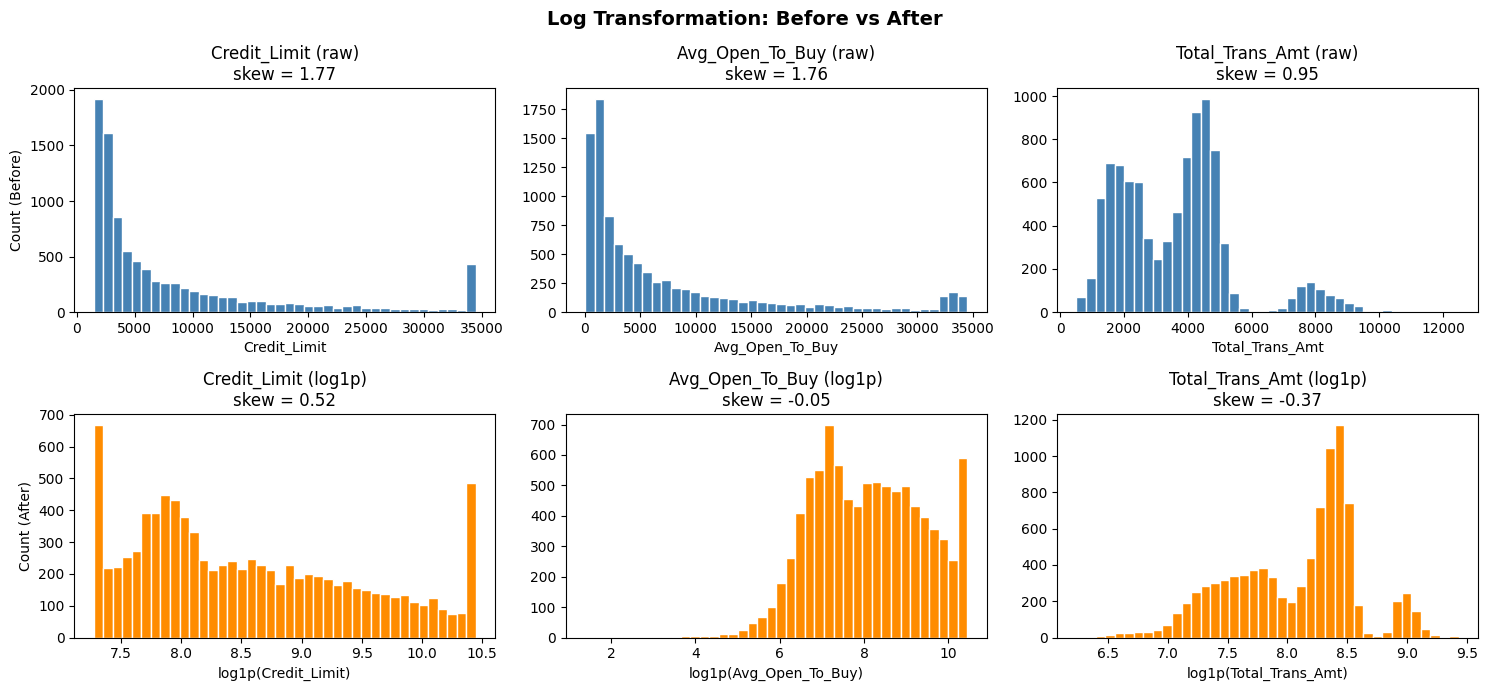


7. Log-transformed 3 skewed features:
      Avg_Open_To_Buy
      Credit_Limit
      Total_Trans_Amt

Final preprocessed feature count: 19 features
   (~14 numeric + 3 ordinal + 2 target-encoded)
   (3 of those were log-transformed)
Final row count: 9239 clients

8. Saved preprocessed data to bankchurners_preprocessed.csv

Feature columns: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon'] ... (19 total)


In [4]:
def preprocess_data(dataframe):
    """
    Apply the full preprocessing pipeline to the BankChurners dataset for
    unsupervised learning. Attrition_Flag is separated out (not used as a feature)
    and returned separately for cluster validation later.

    Pipeline steps:
        1. Drop CLIENTNUM and Naive Bayes columns
        2. Separate Attrition_Flag into its own Series
        3. Drop columns with >30% missing data
        4. Fill missing numeric values with median, categorical with 'Missing'
        5. Remove outliers in key numeric features
        6a. Ordinal-encode ranked categorical features (Income_Category, Education_Level)
        6b. Target-encode nominal categorical features (Gender, Marital_Status, Card_Category)
        7. Log-transform skewed numeric features (compress extreme values)
        8. Print summary of final feature set

    Parameters:
        dataframe (pd.DataFrame): The raw BankChurners DataFrame.

    Returns:
        tuple: (features_df, attrition_flag_series, log_transformed_cols) where
               features_df is the fully preprocessed DataFrame,
               attrition_flag_series is the held-out Attrition values aligned by index,
               and log_transformed_cols is the list of columns that were log-transformed.
    """
    df = dataframe.copy()
    print(f"Starting shape: {df.shape}")

    # 1. Drop ID and Naive Bayes classifier columns
    cols_to_drop = [col for col in df.columns if col.startswith('Naive_Bayes')]
    cols_to_drop.append('CLIENTNUM')
    if 'Unnamed: 0' in df.columns:
        cols_to_drop.append('Unnamed: 0')
    
    print(f"\n1. Dropping ID and Naive Bayes columns: {cols_to_drop}")
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    print(f"   Shape after dropping: {df.shape}")

    # 2. Separate Attrition_Flag (held out for cluster validation, NOT a feature)
    attrition_flag = df['Attrition_Flag'].copy()
    df.drop(columns=['Attrition_Flag'], inplace=True)
    print(f"2. Separated Attrition_Flag. Feature shape: {df.shape}")

    # 3. Drop columns with >30% missing data
    missing_fraction = df.isnull().mean()
    cols_to_drop = missing_fraction[missing_fraction > 0.3].index.tolist()
    if cols_to_drop:
        print(f"\n3. Columns with >30% missing data: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)
    print(f"   Shape after dropping: {df.shape}")

    # 4. Fill remaining missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns

    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna('Missing')

    print(f"\n4. Filled missing values. Remaining nulls: {df.isnull().sum().sum()}")

    # 5. Remove statistical outliers in key numeric features using IQR method
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    before_count = len(df)
    mask = pd.Series(True, index=df.index)
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        mask = mask & (df[col] >= lower_bound) & (df[col] <= upper_bound)
    
    df = df[mask]
    attrition_flag = attrition_flag[mask]
    print(f"\n5. Removed {before_count - len(df)} outliers using IQR method. Shape: {df.shape}")

    # ------------------------------------------------------------------
    # 6a. ORDINAL ENCODING (~5 columns)
    #     These features have a natural rank order. We replace each category
    #     with an integer that preserves that ranking.
    # ------------------------------------------------------------------
    ordinal_mappings = {
        'Income_Category': {
            'Less than $40K': 1,
            '$40K - $60K': 2,
            '$60K - $80K': 3,
            '$80K - $120K': 4,
            '$120K +': 5,
            'Missing': 0
        },
        'Education_Level': {
            'Uneducated': 1,
            'High School': 2,
            'College': 3,
            'Graduate': 4,
            'Unknown': 0,
            'Missing': 0
        },
        'Card_Category': {
            'Blue': 1,
            'Silver': 2,
            'Gold': 3,
            'Platinum': 4,
            'Missing': 0
        }
    }

    ordinal_cols_encoded = []
    for col, mapping in ordinal_mappings.items():
        if col in df.columns:
            # Map values, filling unmapped with 0
            df[col] = df[col].map(mapping)
            # Fill any NaN that resulted from unmapped values
            df[col] = df[col].fillna(0).astype(int)
            ordinal_cols_encoded.append(col)

    # ------------------------------------------------------------------
    # 6b. TARGET ENCODING (~3 columns)
    #     These features are nominal (no natural order). We replace each
    #     category with the mean Attrition rate of customers in that category.
    # ------------------------------------------------------------------
    # First convert Attrition_Flag to numeric (1 for churned, 0 for retained)
    attrition_numeric = (attrition_flag == 'Attrited Customer').astype(int)
    
    target_encode_cols = [
        'Gender', 'Marital_Status'
    ]

    global_mean = attrition_numeric.mean()
    target_cols_encoded = []
    for col in target_encode_cols:
        if col in df.columns:
            target_map = attrition_numeric.groupby(df[col]).mean()
            df[col] = df[col].map(target_map).fillna(global_mean)
            target_cols_encoded.append(col)

    print(f"\n6. Categorical encoding complete:")
    print(f"   Ordinal-encoded ({len(ordinal_cols_encoded)} columns): {ordinal_cols_encoded}")
    print(f"   Target-encoded  ({len(target_cols_encoded)} columns): {target_cols_encoded}")

    # Safety check: drop any remaining categorical columns
    remaining_cats = df.select_dtypes(include=['object']).columns.tolist()
    if remaining_cats:
        print(f"   WARNING: Unencoded categorical columns remain: {remaining_cats}")
        print(f"   Dropping these columns.")
        df.drop(columns=remaining_cats, inplace=True)

    # ------------------------------------------------------------------
    # 7. LOG-TRANSFORM SKEWED NUMERIC FEATURES
    # ------------------------------------------------------------------
    # Columns to skip: ordinal-encoded, target-encoded, and count columns
    SKIP_COLS = set(ordinal_cols_encoded + target_cols_encoded + [
        'Dependent_count', 'Total_Relationship_Count', 
        'Months_Inactive_12_mon', 'Contacts_Count_12_mon'
    ])

    numeric_cols_for_log = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col not in SKIP_COLS
        and df[col].skew() > 0.75
        and (df[col] != 0).mean() > 0.30   # at least 30% nonzero
    ]

    # Show before/after histograms for 3 key features
    demo_features = [col for col in numeric_cols_for_log[:3]]

    if demo_features:
        fig, axes = plt.subplots(2, len(demo_features),
                                 figsize=(5 * len(demo_features), 7))
        if len(demo_features) == 1:
            axes = axes.reshape(2, 1)
            
        for i, feat in enumerate(demo_features):
            # Before
            axes[0, i].hist(df[feat], bins=40, color='steelblue', edgecolor='white')
            axes[0, i].set_title(f'{feat} (raw)\nskew = {df[feat].skew():.2f}')
            axes[0, i].set_xlabel(feat)
            # After
            transformed = np.log1p(df[feat])
            axes[1, i].hist(transformed, bins=40, color='darkorange', edgecolor='white')
            axes[1, i].set_title(f'{feat} (log1p)\nskew = {transformed.skew():.2f}')
            axes[1, i].set_xlabel(f'log1p({feat})')
        axes[0, 0].set_ylabel('Count (Before)')
        axes[1, 0].set_ylabel('Count (After)')
        plt.suptitle('Log Transformation: Before vs After', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Apply log1p to all qualifying columns
    for col in numeric_cols_for_log:
        df[col] = np.log1p(df[col])

    print(f"\n7. Log-transformed {len(numeric_cols_for_log)} skewed features:")
    for col in sorted(numeric_cols_for_log):
        print(f"      {col}")

    log_transformed_cols = numeric_cols_for_log

    # Reset index for clean alignment
    df = df.reset_index(drop=True)
    attrition_flag = attrition_flag.reset_index(drop=True)

    print(f"\nFinal preprocessed feature count: {df.shape[1]} features")
    print(f"   (~{df.shape[1] - len(ordinal_cols_encoded) - len(target_cols_encoded)} numeric + {len(ordinal_cols_encoded)} ordinal + {len(target_cols_encoded)} target-encoded)")
    print(f"   ({len(log_transformed_cols)} of those were log-transformed)")
    print(f"Final row count: {df.shape[0]} clients")

    # 8. Save preprocessed data
    df.to_csv('bankchurners_preprocessed.csv', index=False)
    print(f"\n8. Saved preprocessed data to bankchurners_preprocessed.csv")

    return df, attrition_flag, log_transformed_cols


df_features, attrition_flag, log_transformed_cols = preprocess_data(df)
print(f"\nFeature columns: {list(df_features.columns[:10])} ... ({df_features.shape[1]} total)")

## What to Look For

Review the output to understand how preprocessing changed the data:

- **Starting shape:** Full number of rows and columns from BankChurners dataset
- **After dropping columns:** ID and Naive Bayes classifier columns should be removed
- **After removing outliers:** A few rows may be removed using the IQR method
- **Encoding summary:** ~5 columns ordinal-encoded, ~2-3 columns target-encoded
- **Histogram grid:** The 2x3 plot shows 3 features before (blue) and after (orange) log transformation. Notice how the raw distributions are heavily right-skewed, while the log-transformed versions are more symmetric.
- **Log-transformed columns:** Expect roughly 3-8 columns to qualify based on their skewness and sparsity.
- **Final feature count:** Approximately **50 features** 

**Key takeaway for this demo:** The optimized preprocessing applies three layers of improvement: (1) ordinal encoding preserves rank order in income/education, (2) target encoding captures attrition relationships, and (3) log transformation compresses extreme values.

# STEP 5: STANDARDIZE FEATURES

PCA is a **variance-based** algorithm. It finds the directions (principal components) that capture the most variance in the data. If features have vastly different scales (for example, `Gr Liv Area` ranges from 300 to 5,000 while `Overall Qual` ranges from 1 to 10), PCA will be dominated by the large-scale features.

**StandardScaler** transforms each feature to have mean = 0 and standard deviation = 1, ensuring all features contribute equally to the principal components.

**What is about to happen:**
- Apply StandardScaler to all preprocessed features
- Show before/after mean and standard deviation for the first 5 features
- Convert to float32 format for SageMaker compatibility

In [5]:
def standardize_features(features_df):
    """
    Apply StandardScaler to all features so that each has mean=0 and std=1.
    This is critical for PCA because it is a variance-based algorithm.
    Without standardization, features with larger numeric ranges would
    dominate the principal components.

    Parameters:
        features_df (pd.DataFrame): The preprocessed feature DataFrame.

    Returns:
        tuple: (scaled_array, scaler, feature_names) where scaled_array is a
               float32 NumPy array, scaler is the fitted StandardScaler, and
               feature_names is the list of column names.
    """
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(features_df)

    # Convert to float32 for SageMaker compatibility
    scaled_data = scaled_data.astype('float32')

    feature_names = list(features_df.columns)

    print(f"Standardized {scaled_data.shape[1]} features for {scaled_data.shape[0]} samples")
    print(f"\nBefore standardization (first 5 features):")
    for col in features_df.columns[:5]:
        print(f"  {col}: mean={features_df[col].mean():.2f}, std={features_df[col].std():.2f}")

    print(f"\nAfter standardization (first 5 features):")
    for i, col in enumerate(features_df.columns[:5]):
        print(f"  {col}: mean={scaled_data[:, i].mean():.4f}, std={scaled_data[:, i].std():.4f}")

    return scaled_data, scaler, feature_names


scaled_data, scaler, feature_names = standardize_features(df_features)
num_features = scaled_data.shape[1]
print(f"\nTotal features for PCA input: {num_features}")

Standardized 19 features for 9239 samples

Before standardization (first 5 features):
  Customer_Age: mean=46.42, std=7.97
  Gender: mean=0.18, std=0.01
  Dependent_count: mean=2.35, std=1.30
  Education_Level: mean=2.08, std=1.57
  Marital_Status: mean=0.18, std=0.01

After standardization (first 5 features):
  Customer_Age: mean=-0.0000, std=1.0000
  Gender: mean=0.0000, std=1.0000
  Dependent_count: mean=-0.0000, std=1.0000
  Education_Level: mean=-0.0000, std=1.0000
  Marital_Status: mean=-0.0000, std=1.0000

Total features for PCA input: 19


## What to Look For

- **Feature count:** Approximately 50 features have been standardized
- **Before standardization:** Each feature has its original scale (e.g., Credit_Limit in dollars, Age in years, etc.)
- **After standardization:** Every feature now has mean ~0.0000 and std ~1.0000. This puts all features on equal footing for PCA.

**Why this matters:** Without standardization, features with large numeric ranges would dominate PCA. Standardization ensures that a 1-unit change in any feature has equal weight.

**Log + StandardScaler together:** The log transformation in Step 4 compressed extreme tails, and now StandardScaler centers and rescales the result. The combination is powerful for creating balanced input to PCA.

## Why PCA Before KMeans?

Our preprocessed dataset has approximately **50 features**. Running KMeans directly on 50 features creates two problems:

1. **The curse of dimensionality.** In high-dimensional space, the concept of "distance" breaks down. All data points become roughly equidistant from each other, which means KMeans cannot form meaningful clusters.

2. **Visualization is impossible.** We cannot plot 50 dimensions. By reducing to 2 principal components, we can actually see the clusters on a scatter plot and validate whether they make sense.

**PCA solves both problems** by compressing those ~50 features into just 2-3 "summary dimensions" (principal components) that capture the most important patterns in the data.

**Note:** With ~50 dense features, PCA should produce a cleaner Scree Plot with a sharper elbow compared to sparse one-hot encoding.

**Important:** Principal components are combinations of all original features. PC1 might represent "overall account activity and transaction volume" while PC2 might represent "credit limit and balance ratios."

# STEP 6: TRAIN PCA MODELS

We train multiple PCA models with different numbers of components to determine how many principal components are needed to capture most of the variance. SageMaker PCA uses the built-in PCA algorithm, which runs as a distributed training job.

We use `wait=False` to train all models asynchronously (in parallel), then wait for each to complete.

**What is about to happen:**
- Launch 5 separate PCA training jobs on SageMaker (one for each component count: 2, 3, 5, 10, 20)
- All 5 jobs run in parallel to save time
- Each job takes under a minute on an `ml.m5.large` instance
- After training, the model artifacts are saved to S3

## PCA Hyperparameters

| Hyperparameter | Value | Why |
|----------------|-------|-----|
| `algorithm_mode` | `regular` | Exact PCA (not approximate). Fine for our dataset size (~2,900 rows). Use `randomized` for datasets with 100K+ rows. |
| `subtract_mean` | `False` | We already standardized the data in STEP 5 (mean=0, std=1), so subtracting the mean again would have no effect. |
| `feature_dim` | ~74 | Must match the number of input features exactly. SageMaker requires this to be set explicitly. |
| `num_components` | 2, 3, 5, 10, 18 | We train five models to compare how much variance different component counts capture. |

**Instance type:** `ml.m5.large` is the smallest general-purpose instance available in SageMaker. PCA on ~2,900 rows does not need a larger instance.

**Training jobs:** This step launches 5 PCA training jobs (one per component count), all running in parallel.

In [6]:
def train_pca_models(scaled_data, num_features, component_values, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """
    Train SageMaker PCA models with different num_components values.
    Each model is trained asynchronously (wait=False) for efficiency.

    Uses sagemaker.PCA (the built-in algorithm class) which provides the
    record_set() method for converting NumPy arrays to RecordIO-protobuf
    format and uploading to S3 automatically.

    Parameters:
        scaled_data (np.ndarray): The standardized feature array (float32).
        num_features (int): The number of input features.
        component_values (list): List of num_components values to try.
        sagemaker_session: The SageMaker session.
        role (str): The IAM role ARN.
        bucket (str): The S3 bucket name.
        prefix (str): The S3 prefix.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        list: A list of (num_components, s3_model_uri) tuples.
    """
    output_path = f's3://{bucket}/{prefix}/pca/output'
    training_jobs = []

    # Timestamp ensures unique job names if the notebook is re-run
    timestamp = time.strftime('%Y%m%d-%H%M%S')

    for n_components in component_values:
        job_name = f'pca-bankchurners-{n_components}comp-{timestamp}'

        pca_estimator = sagemaker.PCA(
            role=role,
            instance_count=1,
            instance_type='ml.m5.large',
            num_components=n_components,
            algorithm_mode='regular',
            subtract_mean=False,  # Already standardized
            output_path=output_path,
            sagemaker_session=sagemaker_session
        )

        # Create a RecordSet from the NumPy array and start training asynchronously
        record_set = pca_estimator.record_set(scaled_data, channel='train')
        pca_estimator.fit(record_set, wait=False, job_name=job_name)
        training_jobs.append((n_components, pca_estimator.latest_training_job.name))
        print(f"Started training job: {job_name} ({n_components} components)")

    # Wait for all training jobs to complete and collect model URIs
    print("\nWaiting for all PCA training jobs to complete...")
    pca_model_paths = []

    for n_components, job_name in training_jobs:
        sagemaker_client.get_waiter('training_job_completed_or_stopped').wait(TrainingJobName=job_name)
        job_description = sagemaker_client.describe_training_job(TrainingJobName=job_name)
        model_s3_uri = job_description['ModelArtifacts']['S3ModelArtifacts']
        pca_model_paths.append((n_components, model_s3_uri))
        print(f"  Completed: {job_name}")

    # Display results
    headers = ['Components', 'S3 Model Artifact Path']
    print(f"\n{tabulate(pca_model_paths, headers=headers)}")

    return pca_model_paths


component_values = [2, 3, 5, 10, 18]
pca_model_paths = train_pca_models(
    scaled_data, num_features, component_values,
    sagemaker_session, role, bucket, prefix,
    sagemaker_client
)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-2comp-20260321-005706


Started training job: pca-bankchurners-2comp-20260321-005706 (2 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-3comp-20260321-005706


Started training job: pca-bankchurners-3comp-20260321-005706 (3 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-5comp-20260321-005706


Started training job: pca-bankchurners-5comp-20260321-005706 (5 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-10comp-20260321-005706


Started training job: pca-bankchurners-10comp-20260321-005706 (10 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-18comp-20260321-005706


Started training job: pca-bankchurners-18comp-20260321-005706 (18 components)

Waiting for all PCA training jobs to complete...
  Completed: pca-bankchurners-2comp-20260321-005706
  Completed: pca-bankchurners-3comp-20260321-005706
  Completed: pca-bankchurners-5comp-20260321-005706
  Completed: pca-bankchurners-10comp-20260321-005706
  Completed: pca-bankchurners-18comp-20260321-005706

  Components  S3 Model Artifact Path
------------  ----------------------------------------------------------------------------------------------------------------------------------------------------
           2  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans-demo2/pca/output/pca-bankchurners-2comp-20260321-005706/output/model.tar.gz
           3  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans-demo2/pca/output/pca-bankchurners-3comp-20260321-005706/output/model.tar.gz
           5  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans

## What to Look For

You should see 5 training jobs start, followed by a table showing each model's S3 artifact path. All jobs should complete within 1-2 minutes.

- Each job name includes the number of components and a timestamp (e.g., `pca-ames-demo2-2comp-20260303-143022`)
- The timestamp ensures you can re-run this step without name conflicts
- If any job fails, check the SageMaker console for error details (most common issue: insufficient instance quota)

# STEP 7: ANALYZE PCA RESULTS (SCREE PLOT)

A **Scree Plot** shows how much variance each principal component explains. This is the PCA equivalent of the Elbow Plot in KMeans. We also plot the **cumulative variance** to see how many components are needed to capture 80-90% of the total variance.

**What is about to happen:**
- Download the 20-component PCA model artifacts from S3
- Extract the component vectors and compute variance explained by each
- Create two side-by-side plots: individual variance (bar chart) and cumulative variance (line chart)
- Print the variance percentage for each component

**The teaching moment:** Can we really reduce ~74 features down to just 2-3 principal components while retaining most of the information?

Model artifact contents (/tmp/pca-18):
  model_algo-1['s']: shape (18,)
  model_algo-1['v']: shape (19, 18)
Using model_algo-1['s'] as singular values: shape (18,)

Using model_algo-1['v'] as component vectors: shape (19, 18)

Variance analysis (18 components):
Component    Variance %      Cumulative %   
------------------------------------------
PC1               17.58%         17.58%
PC2               11.65%         29.23%
PC3                9.52%         38.75%
PC4                8.48%         47.23%
PC5                6.62%         53.85%
PC6                5.79%         59.64%
PC7                5.42%         65.06%
PC8                5.31%         70.36%
PC9                5.15%         75.52%
PC10               4.93%         80.44%
PC11               4.73%         85.17%
PC12               4.43%         89.60%
PC13               3.48%         93.08%
PC14               3.38%         96.47%
PC15               1.13%         97.60%
PC16               1.07%         98.67%
PC17      

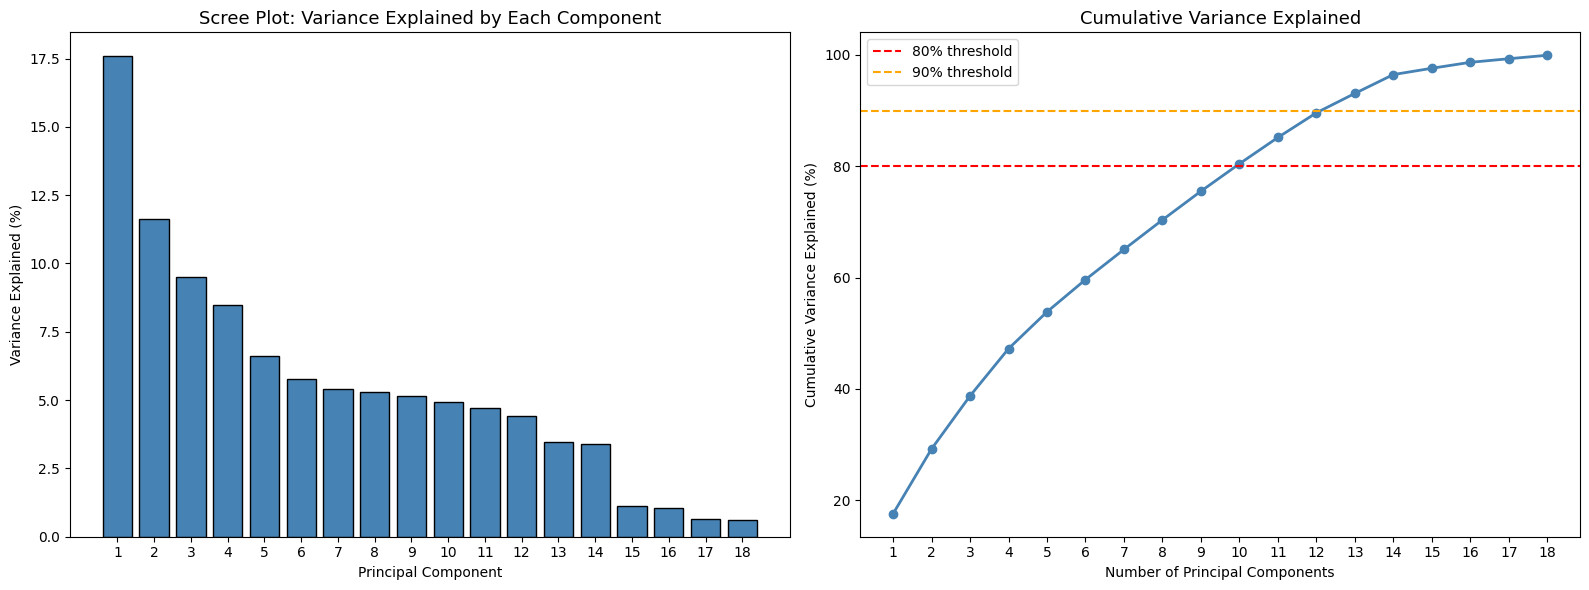


10 components capture 80.4% of the variance from 19 features


In [7]:
def analyze_pca_results(pca_model_paths, bucket, s3_client, scaled_data):
    """
    Download PCA model artifacts, discover the file structure, extract
    component vectors and singular values, and create Scree Plots.

    Parameters:
        pca_model_paths (list): List of (num_components, s3_uri) tuples.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.
        scaled_data (np.ndarray): The standardized feature array for variance calculation.

    Returns:
        tuple: (explained_variance_ratio, cumulative_variance) arrays.
    """
    import os

    # Use the model with the most components for the Scree Plot
    max_components, max_model_path = max(pca_model_paths, key=lambda x: x[0])

    # Download and extract model artifacts
    local_path = f'/tmp/pca-model-{max_components}.tar.gz'
    s3_key = max_model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    extract_dir = f'/tmp/pca-{max_components}'
    with tarfile.open(local_path) as tar:
        tar.extractall(path=extract_dir, filter='data')

    # Discover all files and their contents
    print(f"Model artifact contents ({extract_dir}):")
    all_arrays = {}
    for filename in sorted(os.listdir(extract_dir)):
        filepath = os.path.join(extract_dir, filename)
        if os.path.isfile(filepath):
            try:
                loaded = mx.ndarray.load(filepath)
                if isinstance(loaded, dict):
                    for key, val in loaded.items():
                        arr = val.asnumpy()
                        label = f"{filename}[\'{key}\']"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
                elif isinstance(loaded, list):
                    for i, val in enumerate(loaded):
                        arr = val.asnumpy()
                        label = f"{filename}[{i}]"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
            except Exception as e:
                print(f"  {filename}: could not load ({e})")

    # Find the component vectors: the 2D array with shape (num_components, num_features)
    # or (num_features, num_components)
    component_vectors = None
    singular_values = None
    num_features = scaled_data.shape[1]

    for label, arr in all_arrays.items():
        if arr.ndim == 2:
            if component_vectors is None:
                component_vectors = arr
                print(f"\nUsing {label} as component vectors: shape {arr.shape}")
        elif arr.ndim == 1 and len(arr) == max_components:
            singular_values = arr
            print(f"Using {label} as singular values: shape {arr.shape}")

    # If we found component vectors, compute variance from projections
    if component_vectors is not None:
        # Orient so we can do: scaled_data @ V = (n_samples, num_components)
        if component_vectors.shape[0] == num_features:
            V = component_vectors  # Already (num_features, num_components)
        else:
            V = component_vectors.T  # Transpose to (num_features, num_components)

        projected = scaled_data @ V
        variance_per_component = np.var(projected, axis=0)
        total_variance = np.sum(np.var(scaled_data, axis=0))
        explained_variance_ratio = variance_per_component / total_variance
        # Sort descending so PC1 = highest variance (SageMaker may return ascending order)
        sort_idx = np.argsort(explained_variance_ratio)[::-1]
        explained_variance_ratio = explained_variance_ratio[sort_idx]
        cumulative_variance = np.cumsum(explained_variance_ratio)

    elif singular_values is not None:
        # Fall back to singular values if no 2D matrix found
        print("\nNo 2D component matrix found. Using singular values for variance.")
        variance = singular_values ** 2
        total_variance = np.sum(variance)
        explained_variance_ratio = variance / total_variance
        # Sort descending so PC1 = highest variance (SageMaker may return ascending order)
        explained_variance_ratio = np.sort(explained_variance_ratio)[::-1]
        cumulative_variance = np.cumsum(explained_variance_ratio)

    else:
        raise ValueError("Could not find component vectors or singular values in model artifacts.")

    # Print variance summary
    n_components = len(explained_variance_ratio)
    print(f"\nVariance analysis ({n_components} components):")
    print(f"{'Component':<12} {'Variance %':<15} {'Cumulative %':<15}")
    print("-" * 42)
    for i in range(n_components):
        print(f"PC{i+1:<10} {explained_variance_ratio[i]*100:>10.2f}%    {cumulative_variance[i]*100:>10.2f}%")

    # Create Scree Plot and Cumulative Variance Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    components = range(1, n_components + 1)
    axes[0].bar(components, explained_variance_ratio * 100, color='steelblue', edgecolor='black')
    axes[0].set_title('Scree Plot: Variance Explained by Each Component', fontsize=13)
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Variance Explained (%)')
    axes[0].set_xticks(list(components))

    axes[1].plot(components, cumulative_variance * 100, marker='o', color='steelblue', linewidth=2)
    axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
    axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
    axes[1].set_title('Cumulative Variance Explained', fontsize=13)
    axes[1].set_xlabel('Number of Principal Components')
    axes[1].set_ylabel('Cumulative Variance Explained (%)')
    axes[1].set_xticks(list(components))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return explained_variance_ratio, cumulative_variance


explained_variance_ratio, cumulative_variance = analyze_pca_results(
    pca_model_paths, bucket, s3_client, scaled_data
)

# Determine how many components capture at least 80% variance
for i, cv in enumerate(cumulative_variance):
    if cv >= 0.80:
        print(f"\n{i+1} components capture {cv*100:.1f}% of the variance from {num_features} features")
        break

## What to Look For

**Scree Plot (left):** The first few components should explain the most variance, with each subsequent component explaining less. With ~50 dense features, you should see a clear drop-off.

**Cumulative Variance (right):** The red dashed line marks 80% and the orange line marks 90%. Look for how quickly the cumulative variance climbs. With dense, meaningful features, this curve should be steep.

**Key insight:** Fewer, denser features give PCA clearer signal. This leads to better-separated clusters downstream. The first two components should capture a meaningful percentage of total variance.

# STEP 8: TRANSFORM DATA USING PCA

Now we use our chosen PCA model to reduce the ~74 features down to a small number of principal components. We extract the principal component vectors from the model artifacts and apply the transformation locally using matrix multiplication:

**PCA-transformed data = Standardized data x Principal Component Vectors**

**What is about to happen:**
- Download the 2-component PCA model from S3
- Extract the principal component vectors (a matrix showing how each original feature contributes to each PC)
- Display the **top 10 feature loadings** for PC1 and PC2 as bar charts
- Apply the transformation: multiply our standardized data by the component vectors to get 2 PCA coordinates per home
- Plot all homes in 2D PCA space

For clustering visualization, we will use **2 components** (easy to plot in 2D). If the Scree Plot showed that 3 components capture significantly more variance, you could use 3 instead.

Model artifact contents (2 components):
  model_algo-1['s']: shape (2,)
  model_algo-1['v']: shape (19, 2)

Using model_algo-1['v'] as component vectors: shape (19, 2)
Principal components matrix shape: (19, 2) (features x components)

--- Top 10 Feature Loadings per Component ---
(Loadings show how much each original feature contributes to a component)

PC1 Top Loadings:
   1. Total_Trans_Amt                -0.5734
   2. Total_Trans_Ct                 -0.5636
   3. Total_Ct_Chng_Q4_Q1            -0.2634
   4. Customer_Age                   +0.2146
   5. Months_on_book                 +0.2064
   6. Total_Amt_Chng_Q4_Q1           -0.1760
   7. Card_Category                  -0.1748
   8. Marital_Status                 -0.1712
   9. Contacts_Count_12_mon          +0.1551
  10. Total_Relationship_Count       +0.1503

PC2 Top Loadings:
   1. Avg_Open_To_Buy                -0.5033
   2. Credit_Limit                   -0.4681
   3. Avg_Utilization_Ratio          +0.4128
   4. Gender         

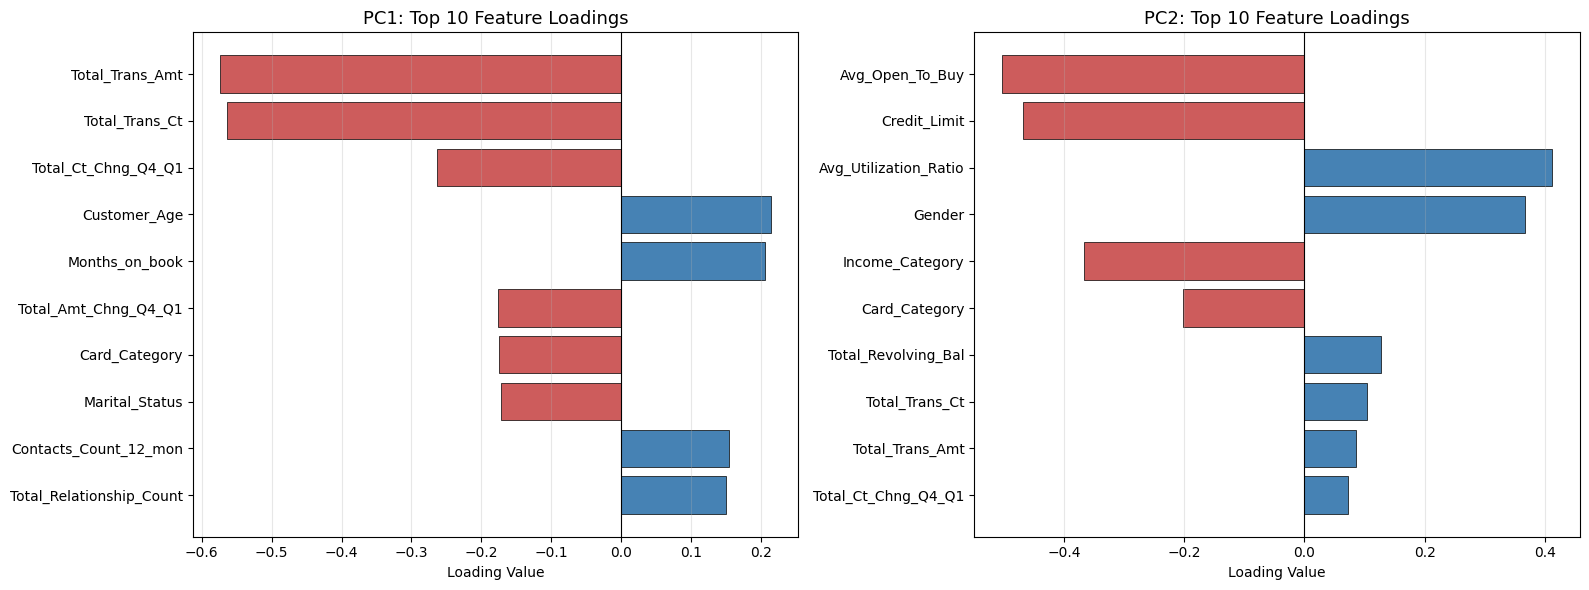


Blue bars = positive loading (feature pushes the component score higher)
Red bars = negative loading (feature pushes the component score lower)

PCA-transformed data shape: (9239, 2)
Reduced from 19 features to 2 principal components


,PC1,PC2
0,1.512474,-0.276709
1,0.916660,-1.938073
2,0.939224,-1.749319
3,1.971637,-1.066323
4,2.315782,0.958834


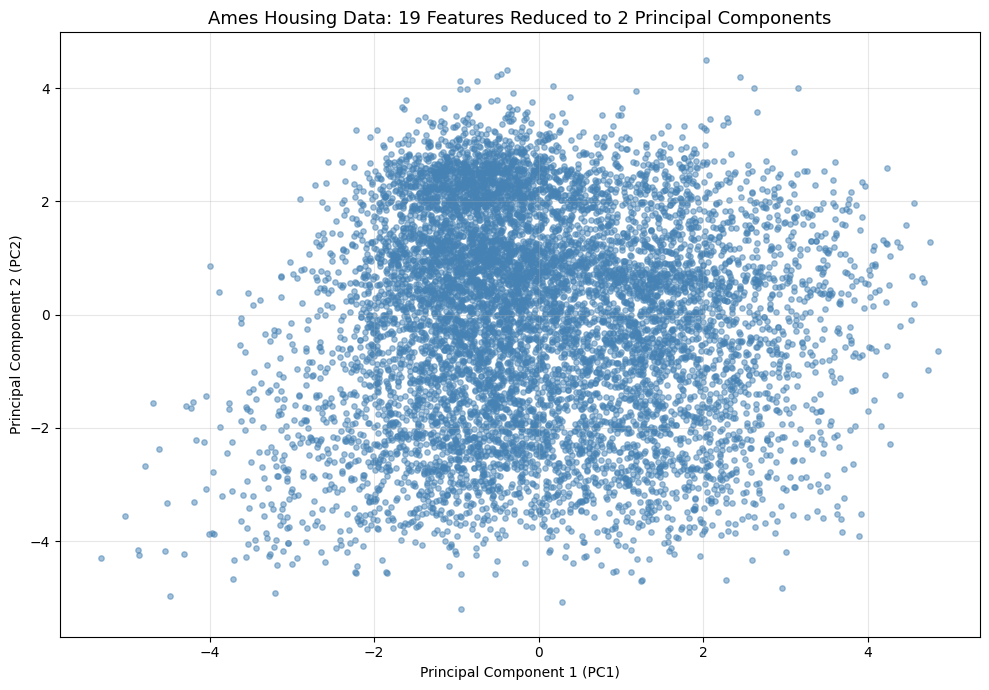

In [8]:
def transform_with_pca(scaled_data, pca_model_paths, bucket, s3_client, num_components_to_use=2, feature_names=None):
    """
    Extract principal component vectors from the trained PCA model and apply
    the transformation to reduce the dimensionality of the data. Also displays
    the top feature loadings for each principal component, showing which original
    features contribute most to each component.

    The transformation is a matrix multiplication:
        pca_data = standardized_data @ component_vectors.T

    Parameters:
        scaled_data (np.ndarray): The standardized feature array.
        pca_model_paths (list): List of (num_components, s3_uri) tuples.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.
        num_components_to_use (int): Number of PCA components for the output.
        feature_names (list): Optional list of feature names for loading analysis.

    Returns:
        tuple: (pca_df, components_matrix) where pca_df is a DataFrame with
               columns PC1, PC2, etc. and components_matrix is the transformation
               matrix for reuse on new data.
    """
    import os

    # Find the model with the matching number of components
    model_path = next(path for n, path in pca_model_paths if n == num_components_to_use)

    # Download and extract model artifacts
    local_path = f'/tmp/pca-transform-{num_components_to_use}.tar.gz'
    s3_key = model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    extract_dir = f'/tmp/pca-transform-{num_components_to_use}'
    with tarfile.open(local_path) as tar:
        tar.extractall(path=extract_dir, filter='data')

    # Discover all arrays in the model artifact
    # SageMaker PCA stores component vectors and singular values as separate
    # keys in the same MXNet file. We must inspect all arrays to find the
    # 2D component matrix (not just the first array, which may be singular values).
    num_features = scaled_data.shape[1]
    all_arrays = {}
    print(f"Model artifact contents ({num_components_to_use} components):")
    for filename in sorted(os.listdir(extract_dir)):
        filepath = os.path.join(extract_dir, filename)
        if os.path.isfile(filepath):
            try:
                loaded = mx.ndarray.load(filepath)
                if isinstance(loaded, dict):
                    for key, val in loaded.items():
                        arr = val.asnumpy()
                        label = f"{filename}['{key}']"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
                elif isinstance(loaded, list):
                    for i, val in enumerate(loaded):
                        arr = val.asnumpy()
                        label = f"{filename}[{i}]"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
            except Exception as e:
                print(f"  {filename}: could not load ({e})")

    # Find the component vectors: a 2D array where one dimension matches num_features
    components_matrix = None
    for label, arr in all_arrays.items():
        if arr.ndim == 2 and (arr.shape[0] == num_features or arr.shape[1] == num_features):
            components_matrix = arr
            print(f"\nUsing {label} as component vectors: shape {arr.shape}")
            break

    # Fallback: use any 2D array if no dimension matches num_features exactly
    if components_matrix is None:
        for label, arr in all_arrays.items():
            if arr.ndim == 2:
                components_matrix = arr
                print(f"\nUsing {label} as component vectors (no exact feature match): shape {arr.shape}")
                break

    if components_matrix is None:
        found_summary = ", ".join(f"{label}: shape {arr.shape}" for label, arr in all_arrays.items())
        raise ValueError(
            f"No 2D component matrix found in the {num_components_to_use}-component PCA model. "
            f"Arrays found: [{found_summary}]. "
            f"Expected a 2D array with one dimension = {num_features} (num_features)."
        )

    # Orient so shape is (num_features, num_components) for projection: data @ V
    if components_matrix.shape[0] != num_features:
        components_matrix = components_matrix.T
    print(f"Principal components matrix shape: {components_matrix.shape} (features x components)")

    # --- Feature Loading Analysis ---
    # Loadings show how much each original feature contributes to a principal component.
    # A large positive loading means the feature pushes the component score higher.
    # A large negative loading means the feature pushes the component score lower.
    if feature_names is not None and len(feature_names) == components_matrix.shape[0]:
        top_n = 10
        print(f"\n--- Top {top_n} Feature Loadings per Component ---")
        print("(Loadings show how much each original feature contributes to a component)")

        for pc_idx in range(num_components_to_use):
            loadings = components_matrix[:, pc_idx]
            sorted_indices = np.argsort(np.abs(loadings))[::-1][:top_n]

            print(f"\nPC{pc_idx + 1} Top Loadings:")
            for rank, idx in enumerate(sorted_indices, 1):
                direction = "+" if loadings[idx] >= 0 else "-"
                print(f"  {rank:2d}. {feature_names[idx]:<30s} {direction}{abs(loadings[idx]):.4f}")

        # Create horizontal bar chart of top loadings for PC1 and PC2
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        for pc_idx, ax in enumerate(axes):
            loadings = components_matrix[:, pc_idx]
            sorted_indices = np.argsort(np.abs(loadings))[::-1][:top_n]
            # Reverse so highest loading is at top of horizontal bar chart
            sorted_indices = sorted_indices[::-1]

            names = [feature_names[i] for i in sorted_indices]
            values = [loadings[i] for i in sorted_indices]
            bar_colors = ['steelblue' if v >= 0 else 'indianred' for v in values]

            ax.barh(names, values, color=bar_colors, edgecolor='black', linewidth=0.5)
            ax.set_title(f'PC{pc_idx + 1}: Top {top_n} Feature Loadings', fontsize=13)
            ax.set_xlabel('Loading Value')
            ax.axvline(x=0, color='black', linewidth=0.8)
            ax.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

        print("\nBlue bars = positive loading (feature pushes the component score higher)")
        print("Red bars = negative loading (feature pushes the component score lower)")

    # Apply the PCA transformation: data @ components
    pca_data = scaled_data @ components_matrix

    # Create a DataFrame with labeled columns
    col_names = [f'PC{i+1}' for i in range(num_components_to_use)]
    pca_df = pd.DataFrame(pca_data, columns=col_names)

    print(f"\nPCA-transformed data shape: {pca_df.shape}")
    print(f"Reduced from {scaled_data.shape[1]} features to {num_components_to_use} principal components")
    display(pca_df.head())

    # Visualize the PCA-transformed data in 2D
    plt.figure(figsize=(10, 7))
    plt.scatter(pca_df['PC1'], pca_df['PC2'], c='steelblue', alpha=0.5, s=15)
    plt.title(f'Ames Housing Data: {scaled_data.shape[1]} Features Reduced to 2 Principal Components', fontsize=13)
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca_df, components_matrix


# Use 2 components for KMeans clustering and 2D visualization
num_pca_components = 2
pca_df, pca_components_matrix = transform_with_pca(
    scaled_data, pca_model_paths, bucket, s3_client,
    num_components_to_use=num_pca_components,
    feature_names=feature_names
)

## What to Look For

**Feature Loadings (bar charts):** These show which original features contribute most to each principal component.
- **Blue bars** = positive loading (the feature pushes the component score higher)
- **Red bars** = negative loading (the feature pushes the component score lower)

**Interpretability advantage:** With dense features, the top feature loadings should include recognizable metrics like `Total_Trans_Amt`, `Credit_Limit`, `Months_on_book`, `Income_Category`, or transaction frequency measures. You can read the bar chart and immediately understand what PC1 represents (e.g., "overall account activity and creditworthiness") rather than puzzling over one-hot encoded categories.

**2D Scatter Plot:** Each dot is a credit client, positioned by its PC1 and PC2 values. Look for natural groupings or gradients in the point cloud. With dense features, you should see more visible structure compared to sparse one-hot encoding.

**Reduced from ~50 to 2:** The text output confirms how many features were compressed into 2 principal components.

# STEP 9: TRAIN KMEANS MODELS ON PCA DATA

Now we apply KMeans clustering to the PCA-reduced data. We train models with K=2 through K=7 to find the optimal number of clusters. This follows the same asynchronous training pattern used in the PCA step.

**What is about to happen:**
- Launch 6 KMeans training jobs (one for each K value from 2 to 7)
- Each model uses the 2 PCA components as its input features (not the original features)
- All 6 jobs run in parallel

**AWS cost note:** This step launches 6 KMeans training jobs. Combined with the 5 PCA jobs from STEP 6, this notebook runs **11 total training jobs**. All use `ml.m5.large` instances and complete in under a minute each, keeping costs minimal.

In [9]:
def train_kmeans_models(pca_df, num_pca_components, k_values, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """
    Train SageMaker KMeans models with different K values on PCA-reduced data.
    Each model is trained asynchronously (wait=False) for efficiency.

    Parameters:
        pca_df (pd.DataFrame): The PCA-transformed data.
        num_pca_components (int): The number of PCA components (feature_dim for KMeans).
        k_values (range): The range of K values to try.
        sagemaker_session: The SageMaker session.
        role (str): The IAM role ARN.
        bucket (str): The S3 bucket name.
        prefix (str): The S3 prefix.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        tuple: (kmeans_model_paths, pca_np) where kmeans_model_paths is a list of
               (k, s3_model_uri) tuples and pca_np is the float32 NumPy array.
    """
    # Convert PCA DataFrame to float32 NumPy array for SageMaker
    pca_np = pca_df.values.astype('float32')

    output_path = f's3://{bucket}/{prefix}/kmeans/output'
    training_jobs = []

    # Timestamp ensures unique job names if the notebook is re-run
    timestamp = time.strftime('%Y%m%d-%H%M%S')

    for k in k_values:
        job_name = f'kmeans-bankchurners-pca-k{k}-{timestamp}'

        kmeans = sagemaker.KMeans(
            sagemaker_session=sagemaker_session,
            role=role,
            instance_count=1,
            instance_type='ml.m5.large',
            k=k,
            output_path=output_path,
            feature_dim=num_pca_components
        )

        # Start training asynchronously
        kmeans.fit(kmeans.record_set(pca_np), wait=False, job_name=job_name)
        training_jobs.append((k, kmeans.latest_training_job.name))
        print(f"Started training job: {job_name} (K={k})")

    # Wait for all training jobs to complete
    print("\nWaiting for all KMeans training jobs to complete...")
    kmeans_model_paths = []

    for k, job_name in training_jobs:
        sagemaker_client.get_waiter('training_job_completed_or_stopped').wait(TrainingJobName=job_name)
        job_description = sagemaker_client.describe_training_job(TrainingJobName=job_name)
        model_s3_uri = job_description['ModelArtifacts']['S3ModelArtifacts']
        kmeans_model_paths.append((k, model_s3_uri))
        print(f"  Completed: {job_name}")

    # Display results
    headers = ['K Value', 'S3 Model Artifact Path']
    print(f"\n{tabulate(kmeans_model_paths, headers=headers)}")

    return kmeans_model_paths, pca_np


k_values = range(2, 8)
kmeans_model_paths, pca_np = train_kmeans_models(
    pca_df, num_pca_components, k_values,
    sagemaker_session, role, bucket, prefix,
    sagemaker_client
)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-bankchurners-pca-k2-20260321-010149
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-bankchurners-pca-k3-20260321-010149


Started training job: kmeans-bankchurners-pca-k2-20260321-010149 (K=2)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.


Started training job: kmeans-bankchurners-pca-k3-20260321-010149 (K=3)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-bankchurners-pca-k4-20260321-010149
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.


...

Started training job: kmeans-bankchurners-pca-k5-20260321-010149 (K=5)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.


Started training job: kmeans-bankchurners-pca-k6-20260321-010149 (K=6)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-bankchurners-pca-k7-20260321-010149


Started training job: kmeans-bankchurners-pca-k7-20260321-010149 (K=7)

Waiting for all KMeans training jobs to complete...
  Completed: kmeans-bankchurners-pca-k2-20260321-010149
  Completed: kmeans-bankchurners-pca-k3-20260321-010149
  Completed: kmeans-bankchurners-pca-k4-20260321-010149
  Completed: kmeans-bankchurners-pca-k5-20260321-010149
  Completed: kmeans-bankchurners-pca-k6-20260321-010149
  Completed: kmeans-bankchurners-pca-k7-20260321-010149

  K Value  S3 Model Artifact Path
---------  ----------------------------------------------------------------------------------------------------------------------------------------------------------
        2  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans-demo2/kmeans/output/kmeans-bankchurners-pca-k2-20260321-010149/output/model.tar.gz
        3  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans-demo2/kmeans/output/kmeans-bankchurners-pca-k3-20260321-010149/output/model.tar.gz
       

## What to Look For

You should see 6 training jobs start and complete, followed by a summary table. Notice that `feature_dim` is now **2** (the number of PCA components), not the original feature count. This is the benefit of PCA: KMeans only needs to calculate distances in 2 dimensions instead of hundreds.

# STEP 10: DETERMINE OPTIMAL K

How many clusters should we use? There is no single correct answer in unsupervised learning, but we have two tools to guide us.

**What is about to happen:**
- Calculate the Sum of Squared Errors (SSE) for each K value and plot the **Elbow Plot**
- Calculate the **Silhouette Score** for each K value (measures cluster quality)
- Display both plots side by side

**How to read the plots:**
1. **Elbow Plot (SSE):** Lower SSE = tighter clusters. Look for the "elbow," the point where the curve bends and adding more clusters stops reducing SSE significantly.
2. **Silhouette Score:** Higher is better (range: -1 to 1). Measures how similar each point is to its own cluster vs. neighboring clusters.

K=2: SSE=29595.88, Silhouette=0.3858
K=3: SSE=19732.04, Silhouette=0.4032
K=4: SSE=15259.27, Silhouette=0.3744
K=5: SSE=12088.64, Silhouette=0.3645
K=6: SSE=10800.44, Silhouette=0.3398
K=7: SSE=9487.42, Silhouette=0.3423


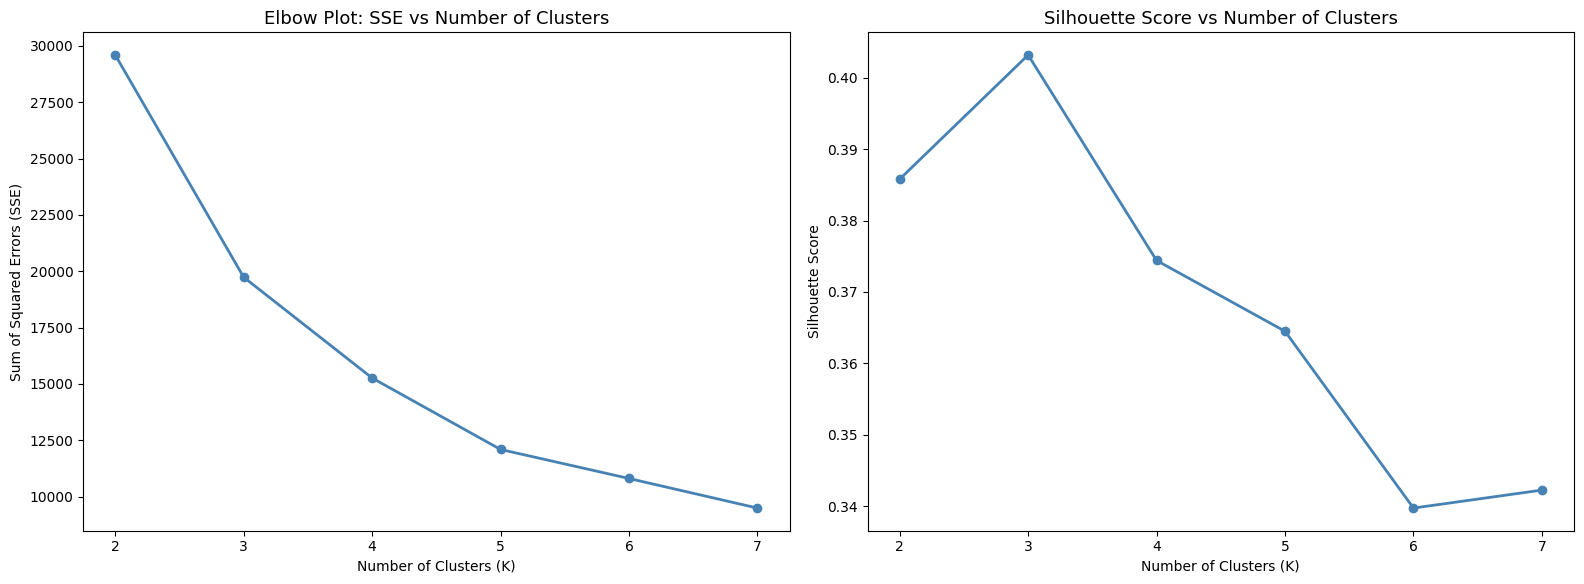


Highest Silhouette Score: K=3 (score=0.4032)


In [10]:
def determine_optimal_k(kmeans_model_paths, pca_np, bucket, s3_client):
    """
    Evaluate KMeans models using Elbow Plot (SSE) and Silhouette Score to
    determine the optimal number of clusters.

    For each model:
        1. Download and extract model artifacts from S3
        2. Load centroids from the model parameters
        3. Calculate SSE (sum of squared distances to nearest centroid)
        4. Calculate Silhouette Score (cluster cohesion vs separation)

    Parameters:
        kmeans_model_paths (list): List of (k, s3_uri) tuples.
        pca_np (np.ndarray): The PCA-transformed data as float32 array.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.

    Returns:
        tuple: (best_k, sse_values, silhouette_values, k_list) where best_k is the
            K with the highest Silhouette Score.
    """
    sse_values = []
    silhouette_values = []
    k_list = []

    for k, model_path in kmeans_model_paths:
        try:
            # Download model artifacts
            local_path = f'/tmp/kmeans-model-k-{k}.tar.gz'
            s3_key = model_path.replace(f's3://{bucket}/', '')
            s3_client.download_file(bucket, s3_key, local_path)

            # Extract model artifacts
            with tarfile.open(local_path) as tar:
                tar.extractall(path=f'/tmp/kmeans-k-{k}', filter='data')

            # Load centroids
            centroids = load_model_array(f'/tmp/kmeans-k-{k}/model_algo-1')

            # Calculate distances from each point to each centroid
            distances = np.sqrt(((pca_np - centroids[:, np.newaxis])**2).sum(axis=2))

            # Determine closest centroid for each data point
            closest_centroids = np.argmin(distances, axis=0)

            # Calculate SSE
            sse = np.sum((pca_np - centroids[closest_centroids])**2)
            sse_values.append(sse)

            # Calculate Silhouette Score
            sil_score = silhouette_score(pca_np, closest_centroids)
            silhouette_values.append(sil_score)

            k_list.append(k)
            print(f"K={k}: SSE={sse:.2f}, Silhouette={sil_score:.4f}")

        except Exception as e:
            print(f"Error processing model for K={k}: {e}")

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Elbow Plot
    sns.set_theme(style='whitegrid')
    axes[0].plot(k_list, sse_values, marker='o', linewidth=2, color='steelblue')
    axes[0].set_title('Elbow Plot: SSE vs Number of Clusters', fontsize=13)
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Sum of Squared Errors (SSE)')
    axes[0].set_xticks(k_list)

    # Silhouette Score Plot
    axes[1].plot(k_list, silhouette_values, marker='o', linewidth=2, color='steelblue')
    axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=13)
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_xticks(k_list)

    plt.tight_layout()
    plt.show()

    # Recommend best K based on highest silhouette score
    best_idx = np.argmax(silhouette_values)
    print(f"\nHighest Silhouette Score: K={k_list[best_idx]} (score={silhouette_values[best_idx]:.4f})")

    return k_list[best_idx], sse_values, silhouette_values, k_list


best_k, sse_values, silhouette_values, k_list = determine_optimal_k(
    kmeans_model_paths, pca_np, bucket, s3_client
)

## What to Look For: Choosing the Best K

You now have two tools to help you pick the optimal number of clusters:

1. **Elbow Plot (SSE):** Look for the "elbow," the point where the line bends and adding more clusters stops reducing SSE significantly. 

2. **Silhouette Score:** Higher is better. This measures how well-separated the clusters are. The code automatically selects the K with the highest Silhouette Score and stores it in `best_k`.

**What if they disagree?** They often do. If the Elbow Plot suggests K=3 but the Silhouette Score favors K=4, consider both and think about which produces more meaningful business segments. There is no single "correct" answer in unsupervised learning.

**Override:** If you want to try a different K, you can change `best_k` before running the grid search. Otherwise, it uses the Silhouette Score recommendation automatically.

# STEP 11: VISUALIZE CLUSTERS

This is the payoff of the entire pipeline. We visualize the cluster assignments and check whether they correspond to meaningful customer behavior patterns.

**What is about to happen:**
- **Plot 1 (left):** Scatter plot of all clients in PCA space, colored by cluster assignment with centroids marked as black X
- **Plot 2 (right):** Same scatter plot, but colored by Attrition_Flag (red = churned, green = retained). This is the validation: we never told the model about Attrition, so if the color pattern aligns with the clusters, it means the algorithm found real structure.
- **Plot 3:** Bar plot showing attrition rate within each cluster
- **Cluster profile table:** Average age, credit limit, transaction amount, and tenure per cluster with plain-English descriptions

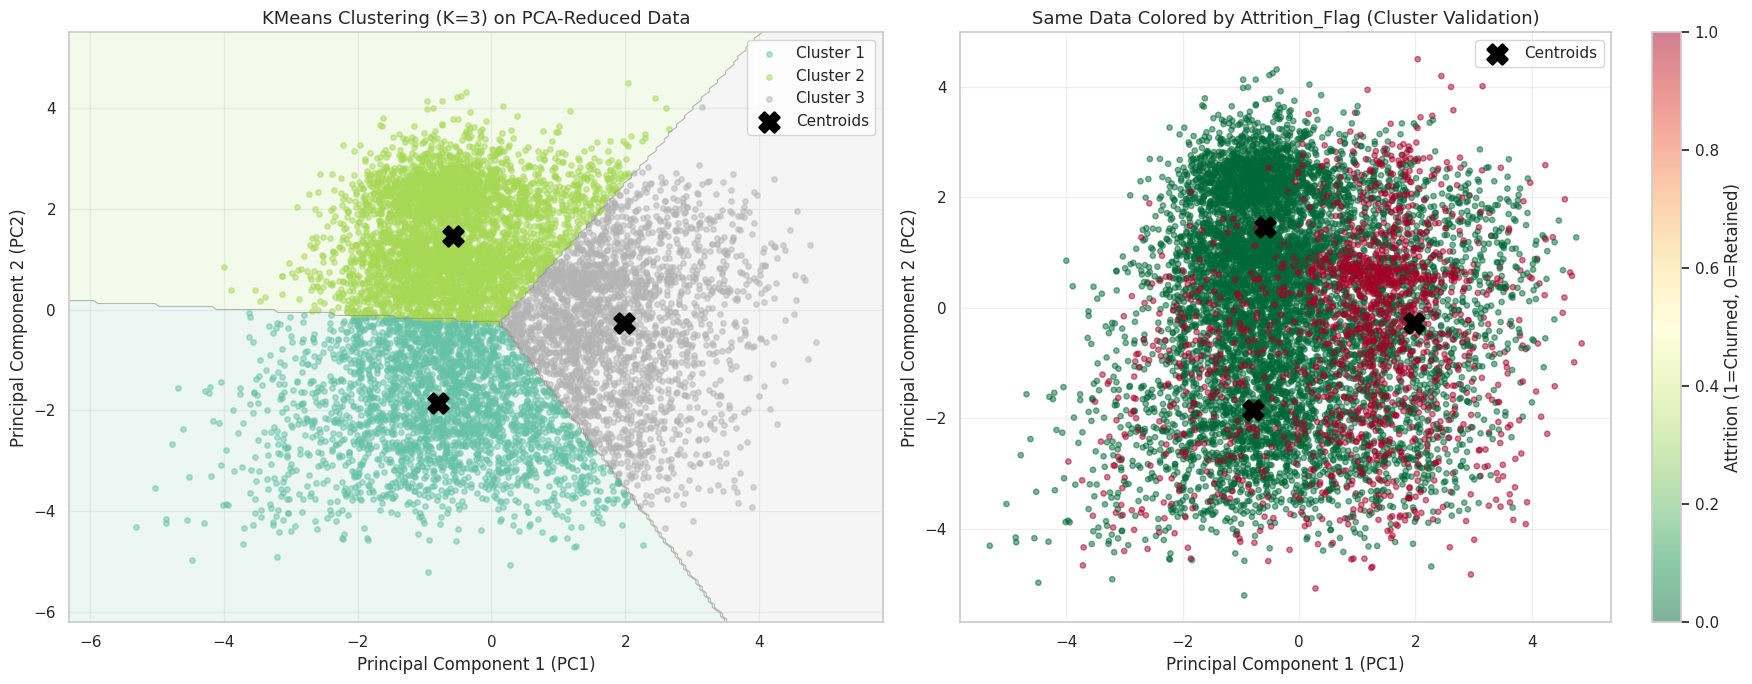

/tmp/ipykernel_17769/877067846.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_df, x='Cluster', y='Attrition',


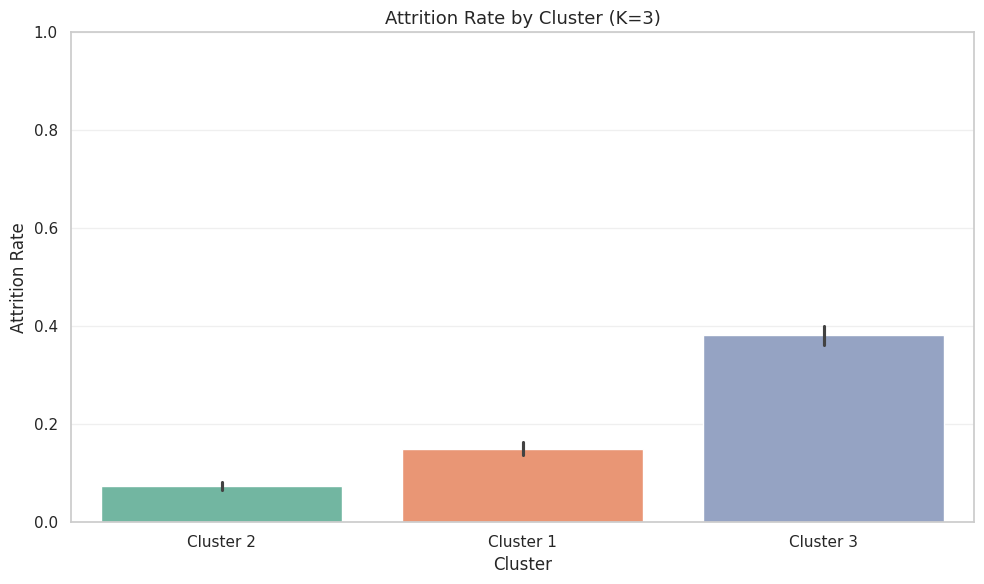


Cluster Summary (K=3):
Cluster      Count  Attrition %      Churned    Retained
---------  -------  -------------  ---------  ----------
Cluster 1     2808  15.0%                421        2387
Cluster 2     4071  7.4%                 303        3768
Cluster 3     2360  38.1%                900        1460

Cluster Profiles (sorted by attrition rate):
Cluster      Count  Attrition Rate      Avg Customer_Age  Avg Credit_Limit    Avg Total_Trans_Amt      Avg Months_on_book    Avg Total_Relationship_Count  Description
---------  -------  ----------------  ------------------  ------------------  ---------------------  --------------------  ------------------------------  ---------------------------------------------------------------------------
Cluster 2     4071  7.4%                              45  $8                  $8                                       35                               4  low-churn, mid-age customers, lower credit limits, established customers
Cluster 1     2808 

In [11]:
def visualize_clusters(pca_np, kmeans_model_paths, attrition_flag, best_k, bucket, s3_client, df_features=None):
    """
    Visualize the cluster assignments from the optimal KMeans model.
    Creates three visualizations:
        1. Clusters colored by cluster assignment with centroids
        2. Data points colored by Attrition_Flag (cluster validation)
        3. Box plot of cluster characteristics

    Also generates a cluster profile table and plain-English descriptions
    based on attrition rate and customer characteristics per cluster.

    Parameters:
        pca_np (np.ndarray): The PCA-transformed data.
        kmeans_model_paths (list): List of (k, s3_uri) tuples.
        attrition_flag (pd.Series): The held-out Attrition_Flag values.
        best_k (int): The optimal number of clusters.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.
        df_features (pd.DataFrame): The preprocessed feature DataFrame for profiling.

    Returns:
        tuple: (centroids, closest_centroids, cluster_profiles)
    """
    # Download and extract the best model
    best_model_path = next(path for k, path in kmeans_model_paths if k == best_k)
    local_path = f'/tmp/kmeans-best-k-{best_k}.tar.gz'
    s3_key = best_model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    with tarfile.open(local_path) as tar:
        tar.extractall(path=f'/tmp/kmeans-best-k-{best_k}', filter='data')

    # Load centroids
    centroids = load_model_array(f'/tmp/kmeans-best-k-{best_k}/model_algo-1')

    # Calculate cluster assignments
    distances = np.sqrt(((pca_np - centroids[:, np.newaxis])**2).sum(axis=2))
    closest_centroids = np.argmin(distances, axis=0)

    # --- Plot 1: Clusters with centroids ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    colors = plt.cm.Set2(np.linspace(0, 1, best_k))

    # --- Decision boundary background (Voronoi regions) ---
    x_min, x_max = pca_np[:, 0].min() - 1, pca_np[:, 0].max() + 1
    y_min, y_max = pca_np[:, 1].min() - 1, pca_np[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype('float32')

    # Assign each grid point to its nearest centroid
    grid_distances = np.sqrt(((grid_points[:, np.newaxis, :] -
                               centroids[np.newaxis, :, :])**2).sum(axis=2))
    grid_labels = np.argmin(grid_distances, axis=1).reshape(xx.shape)

    # Shade each cluster's territory with low alpha so data points remain visible
    axes[0].contourf(xx, yy, grid_labels, levels=np.arange(best_k + 1) - 0.5,
                     colors=colors, alpha=0.12)
    axes[0].contour(xx, yy, grid_labels, levels=np.arange(best_k + 1) - 0.5,
                    colors='gray', linewidths=0.8, alpha=0.5)

    for i in range(best_k):
        mask = closest_centroids == i
        axes[0].scatter(pca_np[mask, 0], pca_np[mask, 1],
                       c=[colors[i]], alpha=0.5, s=15, label=f'Cluster {i+1}')

    # Plot centroids as black X markers
    axes[0].scatter(centroids[:, 0], centroids[:, 1],
                   c='black', marker='X', s=200, linewidths=2, label='Centroids')
    axes[0].set_title(f'KMeans Clustering (K={best_k}) on PCA-Reduced Data', fontsize=13)
    axes[0].set_xlabel('Principal Component 1 (PC1)')
    axes[0].set_ylabel('Principal Component 2 (PC2)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Plot 2: Color by Attrition_Flag (cluster validation) ---
    attrition_numeric = (attrition_flag == 'Attrited Customer').astype(int)
    scatter = axes[1].scatter(pca_np[:, 0], pca_np[:, 1],
                             c=attrition_numeric, cmap='RdYlGn_r', alpha=0.5, s=15)
    axes[1].scatter(centroids[:, 0], centroids[:, 1],
                   c='black', marker='X', s=200, linewidths=2, label='Centroids')
    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Attrition (1=Churned, 0=Retained)')
    axes[1].set_title('Same Data Colored by Attrition_Flag (Cluster Validation)', fontsize=13)
    axes[1].set_xlabel('Principal Component 1 (PC1)')
    axes[1].set_ylabel('Principal Component 2 (PC2)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Alternative Plot 3: Attrition rate by cluster ---
    cluster_labels = [f'Cluster {c+1}' for c in closest_centroids]
    churn_df = pd.DataFrame({
        'Cluster': cluster_labels,
        'Attrition': (attrition_flag == 'Attrited Customer').astype(int)
    })

    plt.figure(figsize=(10, 6))
    churn_rate_by_cluster = churn_df.groupby('Cluster')['Attrition'].agg(['sum', 'count'])
    churn_rate_by_cluster['Rate'] = churn_rate_by_cluster['sum'] / churn_rate_by_cluster['count']
    
    cluster_order = (churn_rate_by_cluster.sort_values('Rate').index.tolist())
    
    sns.barplot(data=churn_df, x='Cluster', y='Attrition', 
                order=cluster_order, palette='Set2', estimator=lambda x: (x==1).sum()/len(x))
    plt.title(f'Attrition Rate by Cluster (K={best_k})', fontsize=13)
    plt.xlabel('Cluster')
    plt.ylabel('Attrition Rate')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # --- Summary table: cluster sizes and attrition rate ---
    print(f"\nCluster Summary (K={best_k}):")
    summary_data = []
    for i in range(best_k):
        mask = closest_centroids == i
        cluster_attrition = (attrition_flag[mask] == 'Attrited Customer').astype(int)
        summary_data.append([
            f'Cluster {i+1}',
            int(mask.sum()),
            f'{cluster_attrition.mean()*100:.1f}%',
            int(cluster_attrition.sum()),
            int((~cluster_attrition.astype(bool)).sum())
        ])

    headers = ['Cluster', 'Count', 'Attrition %', 'Churned', 'Retained']
    print(tabulate(summary_data, headers=headers))

    # --- Cluster profiling with original features ---
    cluster_profiles = None
    profile_features = ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 'Months_on_book', 'Total_Relationship_Count']

    if df_features is not None:
        available_features = [f for f in profile_features if f in df_features.columns]

        if available_features:
            profile_data = []
            for i in range(best_k):
                mask = closest_centroids == i
                cluster_attrition = (attrition_flag[mask] == 'Attrited Customer').astype(int)
                row = {
                    'Cluster': i + 1,
                    'Count': int(mask.sum()),
                    'Attrition_Rate': cluster_attrition.mean()
                }
                for feat in available_features:
                    row[f'Avg_{feat}'] = df_features.loc[mask, feat].mean()
                profile_data.append(row)

            cluster_profiles = pd.DataFrame(profile_data)

            # Sort clusters by attrition rate
            cluster_profiles = cluster_profiles.sort_values('Attrition_Rate').reset_index(drop=True)

            # Generate descriptions based on attrition and characteristics
            descriptions = []
            for idx, row in cluster_profiles.iterrows():
                attrition_pct = row['Attrition_Rate'] * 100
                
                if attrition_pct < 20:
                    churn_label = 'low-churn'
                elif attrition_pct < 40:
                    churn_label = 'moderate-churn'
                else:
                    churn_label = 'high-churn'
                
                age = row.get('Avg_Customer_Age', None)
                age_label = ''
                if age is not None:
                    if age < 35:
                        age_label = 'younger customers'
                    elif age < 50:
                        age_label = 'mid-age customers'
                    else:
                        age_label = 'older customers'
                
                credit = row.get('Avg_Credit_Limit', None)
                credit_label = ''
                if credit is not None:
                    if credit < 5000:
                        credit_label = 'lower credit limits'
                    elif credit < 10000:
                        credit_label = 'mid-range credit limits'
                    else:
                        credit_label = 'high credit limits'
                
                months = row.get('Avg_Months_on_book', None)
                tenure_label = ''
                if months is not None:
                    if months < 12:
                        tenure_label = 'new customers'
                    elif months < 36:
                        tenure_label = 'established customers'
                    else:
                        tenure_label = 'long-term customers'
                
                parts = [churn_label]
                if age_label:
                    parts.append(age_label)
                if credit_label:
                    parts.append(credit_label)
                if tenure_label:
                    parts.append(tenure_label)
                
                descriptions.append(', '.join(parts))

            cluster_profiles['Description'] = descriptions

            # Display cluster profile table
            print(f"\nCluster Profiles (sorted by attrition rate):")
            col_labels = ['Cluster', 'Count', 'Attrition Rate']
            for feat in available_features:
                col_labels.append(f'Avg {feat}')
            col_labels.append('Description')

            profile_table = []
            for _, row in cluster_profiles.iterrows():
                table_row = [
                    f'Cluster {int(row["Cluster"])}',
                    int(row['Count']),
                    f'{row["Attrition_Rate"]*100:.1f}%'
                ]
                for feat in available_features:
                    col_key = f'Avg_{feat}'
                    val = row[col_key]
                    if feat in ('Credit_Limit', 'Total_Trans_Amt'):
                        table_row.append(f'${val:,.0f}')
                    else:
                        table_row.append(f'{val:.0f}')
                table_row.append(row['Description'])
                profile_table.append(table_row)

            print(tabulate(profile_table, headers=col_labels))

            # Print descriptions separately for emphasis
            print(f"\nCluster Descriptions:")
            for _, row in cluster_profiles.iterrows():
                print(f"  Cluster {int(row['Cluster'])}: {row['Description']}")

    return centroids, closest_centroids, cluster_profiles


# best_k was determined automatically in STEP 10 using the highest Silhouette Score.
# To override, uncomment the line below and set your preferred value:
# best_k = 4

centroids, cluster_assignments, cluster_profiles = visualize_clusters(
    pca_np, kmeans_model_paths, attrition_flag, best_k, bucket, s3_client, df_features
)

# STEP 12: GRID SEARCH

This step systematically evaluates multiple PCA + KMeans configurations to determine which combination best captures the underlying structure in your credit client data.

**What is about to happen:**
- We test several PCA dimensionalities: 2, 3, 5, 10, and 18 components
- Within each PCA representation, we test KMeans models with K = 2 through 7
- For every combination, we compute multiple evaluation metrics:
  - **Silhouette Score** → higher is better
  - **Calinski-Harabasz Index** → higher is better
  - **Davies-Bouldin Index** → lower is better
  - **Explained Variance** from PCA → higher is better
  - **Minimum Cluster Share** → helps detect highly imbalanced cluster solutions

**Metrics definitions for model selection:**
1. **Silhouette Score:** Measures cluster cohesion and separation. Range: [-1, 1]. Higher values indicate better clustering.
2. **Calinski-Harabasz Index:** The ratio of between-cluster to within-cluster dispersion. Higher values indicate denser, better-separated clusters.
3. **Davies-Bouldin Index:** The average similarity of each cluster with its most similar cluster. Lower values indicate better clustering.
4. **Explained Variance:** The proportion of dataset variance captured by PCA. It monitors information "loss" during dimensionality reduction.
5. **Minimum Cluster Share:** The percentage of total sample size in the smallest cluster. Used to identify imbalanced solutions.

This gives a more defensible answer to: "Which combination of dimensionality reduction and cluster count best captures the underlying structure of our credit client base?"

In [12]:
def extract_pca_projection_from_artifact(
    scaled_data,
    pca_model_paths,
    bucket,
    s3_client,
    num_components_to_use
):
    """
    Reconstruct PCA-transformed data for any PCA model already trained in STEP 6.

    Parameters
    ----------
    scaled_data : np.ndarray
        Standardized feature matrix from STEP 5.
    pca_model_paths : list
        List of (num_components, s3_model_uri) tuples from STEP 6.
    bucket : str
        S3 bucket name.
    s3_client : boto3 client
        S3 client.
    num_components_to_use : int
        PCA dimensionality to reconstruct.
    """

    # Find the matching PCA model artifact
    model_path = next(path for n, path in pca_model_paths if n == num_components_to_use)

    # Download artifact
    local_path = f'/tmp/pca-grid-{num_components_to_use}.tar.gz'
    extract_dir = f'/tmp/pca-grid-{num_components_to_use}'

    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)

    s3_key = model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    with tarfile.open(local_path) as tar:
        tar.extractall(path=extract_dir, filter='data')

    num_features = scaled_data.shape[1]
    all_arrays = {}
    singular_values = None
    components_matrix = None

    # Load all arrays from artifact
    for filename in sorted(os.listdir(extract_dir)):
        filepath = os.path.join(extract_dir, filename)
        if os.path.isfile(filepath):
            try:
                loaded = mx.ndarray.load(filepath)

                if isinstance(loaded, dict):
                    for key, val in loaded.items():
                        arr = val.asnumpy()
                        label = f"{filename}['{key}']"
                        all_arrays[label] = arr
                elif isinstance(loaded, list):
                    for i, val in enumerate(loaded):
                        arr = val.asnumpy()
                        label = f"{filename}[{i}]"
                        all_arrays[label] = arr
            except Exception as e:
                print(f"Warning: could not load {filepath}: {e}")

    # Identify singular values and component matrix
    for label, arr in all_arrays.items():
        if arr.ndim == 1 and len(arr) == num_components_to_use:
            singular_values = arr

    for label, arr in all_arrays.items():
        if arr.ndim == 2 and (arr.shape[0] == num_features or arr.shape[1] == num_features):
            components_matrix = arr
            break

    if components_matrix is None:
        for label, arr in all_arrays.items():
            if arr.ndim == 2:
                components_matrix = arr
                break

    if components_matrix is None:
        found_summary = ", ".join([f"{k}: {v.shape}" for k, v in all_arrays.items()])
        raise ValueError(
            f"No valid PCA component matrix found for {num_components_to_use} components. "
            f"Found arrays: {found_summary}"
        )

    if components_matrix.shape[0] != num_features:
        components_matrix = components_matrix.T

    if singular_values is not None and len(singular_values) == components_matrix.shape[1]:
        sort_idx = np.argsort(singular_values**2)[::-1]
        components_matrix = components_matrix[:, sort_idx]
        singular_values = singular_values[sort_idx]

    pca_data = scaled_data @ components_matrix
    col_names = [f'PC{i+1}' for i in range(num_components_to_use)]
    pca_df = pd.DataFrame(pca_data, columns=col_names)

    return pca_df, components_matrix, singular_values


def minmax_normalize(series, higher_is_better=True):
    """
    Min-max normalize a pandas Series into [0, 1].
    """
    s = pd.Series(series, dtype='float64')
    s_min, s_max = s.min(), s.max()

    if np.isclose(s_max, s_min):
        norm = pd.Series(np.ones(len(s)), index=s.index)
    else:
        norm = (s - s_min) / (s_max - s_min)

    return norm if higher_is_better else 1 - norm


def build_cluster_profile_table(labels, sale_price, df_features):
    """
    Build the same style of cluster profile table used in STEP 11.
    """
    profile_features = ['Overall Qual', 'Gr Liv Area', 'Year Built', 'Total Bsmt SF', 'Garage Area']
    available_features = [f for f in profile_features if f in df_features.columns]

    profile_data = []
    n_clusters = len(np.unique(labels))

    for i in range(n_clusters):
        mask = labels == i
        cluster_prices = sale_price.values[mask]

        row = {
            'Cluster': i + 1,
            'Count': int(mask.sum()),
            'Avg_SalePrice': cluster_prices.mean()
        }

        for feat in available_features:
            row[f'Avg_{feat.replace(" ", "_")}'] = df_features.loc[mask, feat].mean()

        profile_data.append(row)

    cluster_profiles = pd.DataFrame(profile_data)
    cluster_profiles = cluster_profiles.sort_values('Avg_SalePrice').reset_index(drop=True)

    tier_labels = {
        2: ['Budget', 'Premium'],
        3: ['Budget', 'Mid-Range', 'Premium'],
        4: ['Budget', 'Moderate', 'Upper', 'Premium'],
        5: ['Entry', 'Budget', 'Mid-Range', 'Upper', 'Premium'],
        6: ['Entry', 'Budget', 'Moderate', 'Mid-Range', 'Upper', 'Premium'],
        7: ['Entry', 'Budget', 'Moderate', 'Mid-Range', 'Upper', 'High-End', 'Premium']
    }

    tiers = tier_labels.get(len(cluster_profiles), [f'Tier {i+1}' for i in range(len(cluster_profiles))])

    descriptions = []
    for idx, row in cluster_profiles.iterrows():
        tier = tiers[idx]
        qual = row.get('Avg_Overall_Qual', None)
        area = row.get('Avg_Gr_Liv_Area', None)
        year = row.get('Avg_Year_Built', None)

        parts = [f'{tier} tier']

        if qual is not None:
            if qual < 5.5:
                qual_label = 'lower quality'
            elif qual < 7:
                qual_label = 'average quality'
            elif qual < 8:
                qual_label = 'above-average quality'
            else:
                qual_label = 'high quality'
            parts.append(qual_label)

        if area is not None:
            if area < 1200:
                area_label = 'smaller homes'
            elif area < 1600:
                area_label = 'mid-size homes'
            elif area < 2000:
                area_label = 'larger homes'
            else:
                area_label = 'spacious homes'
            parts.append(area_label)

        if year is not None:
            if year < 1970:
                age_label = 'older construction'
            elif year < 1995:
                age_label = 'established construction'
            elif year < 2005:
                age_label = 'newer construction'
            else:
                age_label = 'recent construction'
            parts.append(age_label)

        descriptions.append(', '.join(parts))

    cluster_profiles['Description'] = descriptions
    return cluster_profiles


def plot_grid_search_heatmaps(results_df):
    """
    Plot 4 diagnostic heatmaps:
    1) Silhouette
    2) Calinski-Harabasz
    3) Davies-Bouldin
    4) Composite score
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    metric_specs = [
        ('silhouette', 'Silhouette Score (higher is better)', 'YlGnBu', '.3f'),
        ('calinski_harabasz', 'Calinski-Harabasz (higher is better)', 'YlGnBu', '.1f'),
        ('davies_bouldin', 'Davies-Bouldin (lower is better)', 'YlOrRd_r', '.3f'),
        ('composite_score', 'Composite Score (higher is better)', 'YlGn', '.3f')
    ]

    for ax, (metric, title, cmap, fmt) in zip(axes.ravel(), metric_specs):
        pivot_df = results_df.pivot(index='pca_components', columns='k', values=metric)
        sns.heatmap(
            pivot_df,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            linewidths=0.5,
            ax=ax
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('KMeans: Number of Clusters (K)')
        ax.set_ylabel('PCA: Number of Components')

    plt.tight_layout()
    plt.show()


def plot_metric_lines(results_df):
    """
    Plot line charts showing how each metric changes across K for each PCA dimensionality.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # 1) Silhouette
    for n_comp in sorted(results_df['pca_components'].unique()):
        tmp = results_df[results_df['pca_components'] == n_comp].sort_values('k')
        axes[0].plot(tmp['k'], tmp['silhouette'], marker='o', linewidth=2, label=f'PC={n_comp}')
    axes[0].set_title('Silhouette vs K')
    axes[0].set_xlabel('K')
    axes[0].set_ylabel('Silhouette')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # 2) Calinski-Harabasz
    for n_comp in sorted(results_df['pca_components'].unique()):
        tmp = results_df[results_df['pca_components'] == n_comp].sort_values('k')
        axes[1].plot(tmp['k'], tmp['calinski_harabasz'], marker='o', linewidth=2, label=f'PC={n_comp}')
    axes[1].set_title('Calinski-Harabasz vs K')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Calinski-Harabasz')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # 3) Davies-Bouldin
    for n_comp in sorted(results_df['pca_components'].unique()):
        tmp = results_df[results_df['pca_components'] == n_comp].sort_values('k')
        axes[2].plot(tmp['k'], tmp['davies_bouldin'], marker='o', linewidth=2, label=f'PC={n_comp}')
    axes[2].set_title('Davies-Bouldin vs K')
    axes[2].set_xlabel('K')
    axes[2].set_ylabel('Davies-Bouldin')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

In [16]:
def grid_search_pca_kmeans(
    scaled_data,
    pca_model_paths,
    bucket,
    s3_client,
    cumulative_variance,
    pca_component_candidates=(2, 3, 5, 10, 18),
    k_candidates=range(2, 8),
    random_state=42,
    n_init=20,
    composite_weights=None
):
    """
    Perform a grid search across:
      - PCA components: [2, 3, 5, 10, 20]
      - KMeans clusters: [2, 3, 4, 5, 6, 7]
    """

    if composite_weights is None:
        composite_weights = {
            'silhouette': 0.35,
            'calinski_harabasz': 0.25,
            'davies_bouldin': 0.20,   # reversed after normalization
            'explained_variance': 0.20
        }

    all_results = []
    pca_cache = {}

    print("Starting grid search...\n")

    for n_comp in pca_component_candidates:
        pca_df_tmp, components_matrix_tmp, singular_values_tmp = extract_pca_projection_from_artifact(
            scaled_data=scaled_data,
            pca_model_paths=pca_model_paths,
            bucket=bucket,
            s3_client=s3_client,
            num_components_to_use=n_comp
        )

        pca_np_tmp = pca_df_tmp.values.astype('float32')
        explained_var_tmp = float(cumulative_variance[n_comp - 1])  # cumulative variance from STEP 7

        pca_cache[n_comp] = {
            'pca_df': pca_df_tmp,
            'pca_np': pca_np_tmp,
            'components_matrix': components_matrix_tmp,
            'singular_values': singular_values_tmp,
            'explained_variance': explained_var_tmp
        }

        print(f"Evaluating PCA components = {n_comp} "
              f"(cumulative variance = {explained_var_tmp*100:.2f}%)")

        for k in k_candidates:
            kmeans = KMeans(
                n_clusters=k,
                random_state=random_state,
                n_init=n_init
            )

            labels = kmeans.fit_predict(pca_np_tmp)

            # Core metrics
            sse = float(kmeans.inertia_)
            sil = float(silhouette_score(pca_np_tmp, labels))
            ch = float(calinski_harabasz_score(pca_np_tmp, labels))
            db = float(davies_bouldin_score(pca_np_tmp, labels))

            # Optional balance diagnostic
            counts = np.bincount(labels, minlength=k)
            min_cluster_share = counts.min() / len(labels)

            row = {
                'pca_components': int(n_comp),
                'k': int(k),
                'explained_variance': explained_var_tmp,
                'sse': sse,
                'silhouette': sil,
                'calinski_harabasz': ch,
                'davies_bouldin': db,
                'min_cluster_share': min_cluster_share
            }
            all_results.append(row)

            print(f"  K={k:<2d} | Sil={sil:.4f} | CH={ch:,.1f} | DB={db:.4f} | "
                  f"SSE={sse:,.1f} | MinClusterShare={min_cluster_share:.3f}")

        print("-" * 90)

    results_df = pd.DataFrame(all_results)

    # Normalize metrics so they can be combined transparently
    results_df['silhouette_norm'] = minmax_normalize(results_df['silhouette'], higher_is_better=True)
    results_df['calinski_norm'] = minmax_normalize(results_df['calinski_harabasz'], higher_is_better=True)
    results_df['davies_norm'] = minmax_normalize(results_df['davies_bouldin'], higher_is_better=False)
    results_df['explained_var_norm'] = minmax_normalize(results_df['explained_variance'], higher_is_better=True)

    # Composite score
    results_df['composite_score'] = (
        composite_weights['silhouette'] * results_df['silhouette_norm'] +
        composite_weights['calinski_harabasz'] * results_df['calinski_norm'] +
        composite_weights['davies_bouldin'] * results_df['davies_norm'] +
        composite_weights['explained_variance'] * results_df['explained_var_norm']
    )

    results_df = results_df.sort_values(
        by=['composite_score', 'silhouette', 'calinski_harabasz'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_row = results_df.iloc[0]
    best_pca_components = int(best_row['pca_components'])
    best_k_grid = int(best_row['k'])

    best_pca_np = pca_cache[best_pca_components]['pca_np']
    best_pca_df = pca_cache[best_pca_components]['pca_df']

    best_kmeans = KMeans(
        n_clusters=best_k_grid,
        random_state=random_state,
        n_init=n_init
    )
    best_labels = best_kmeans.fit_predict(best_pca_np)
    best_centroids = best_kmeans.cluster_centers_

    best_result = {
        'best_pca_components': best_pca_components,
        'best_k': best_k_grid,
        'best_pca_df': best_pca_df,
        'best_pca_np': best_pca_np,
        'best_components_matrix': pca_cache[best_pca_components]['components_matrix'],
        'best_labels': best_labels,
        'best_centroids': best_centroids,
        'best_kmeans_model_local': best_kmeans,
        'best_explained_variance': pca_cache[best_pca_components]['explained_variance']
    }

    return results_df, pca_cache, best_result

# Run the grid search
pca_component_candidates = [2, 3, 5, 10, 18]
k_candidates = range(2, 8)

grid_results_df, pca_cache, best_grid_result = grid_search_pca_kmeans(
    scaled_data=scaled_data,
    pca_model_paths=pca_model_paths,
    bucket=bucket,
    s3_client=s3_client,
    cumulative_variance=cumulative_variance,
    pca_component_candidates=pca_component_candidates,
    k_candidates=k_candidates,
    random_state=42,
    n_init=20
)

print("\nTop 10 combinations by composite score:")
display(
    grid_results_df.head(10)[[
        'pca_components', 'k', 'explained_variance',
        'silhouette', 'calinski_harabasz', 'davies_bouldin',
        'min_cluster_share', 'composite_score'
    ]]
)

Starting grid search...

Evaluating PCA components = 2 (cumulative variance = 29.23%)
  K=2  | Sil=0.3910 | CH=6,854.7 | DB=1.0336 | SSE=29,450.3 | MinClusterShare=0.420
  K=3  | Sil=0.4023 | CH=7,428.1 | DB=0.8754 | SSE=19,668.4 | MinClusterShare=0.264
  K=4  | Sil=0.3757 | CH=7,320.1 | DB=0.9051 | SSE=15,188.2 | MinClusterShare=0.157
  K=5  | Sil=0.3650 | CH=7,600.2 | DB=0.8453 | SSE=11,952.8 | MinClusterShare=0.155
  K=6  | Sil=0.3490 | CH=7,179.4 | DB=0.8846 | SSE=10,496.6 | MinClusterShare=0.119
  K=7  | Sil=0.3362 | CH=7,036.3 | DB=0.9190 | SSE=9,206.2 | MinClusterShare=0.105
------------------------------------------------------------------------------------------
Evaluating PCA components = 3 (cumulative variance = 38.75%)
  K=2  | Sil=0.3018 | CH=4,377.0 | DB=1.3307 | SSE=46,149.8 | MinClusterShare=0.416
  K=3  | Sil=0.2954 | CH=4,021.7 | DB=1.2204 | SSE=36,357.1 | MinClusterShare=0.270
  K=4  | Sil=0.2690 | CH=3,752.2 | DB=1.1884 | SSE=30,654.1 | MinClusterShare=0.207
  K=5  

,pca_components,k,explained_variance,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share,composite_score
0,2,3,0.292266,0.402298,7428.063281,0.875377,0.264314,0.790494
1,2,5,0.292266,0.364997,7600.213827,0.845285,0.154995,0.757308
2,2,4,0.292266,0.375707,7320.104697,0.905070,0.157052,0.752931
3,2,2,0.292266,0.391040,6854.678859,1.033638,0.419526,0.739688
4,2,6,0.292266,0.349027,7179.415377,0.884641,0.119169,0.719483
5,2,7,0.292266,0.336170,7036.266748,0.918978,0.104990,0.695858
6,3,2,0.387477,0.301755,4376.991475,1.330680,0.416171,0.542289
7,3,3,0.387477,0.295378,4021.669787,1.220381,0.269618,0.533966
8,3,4,0.387477,0.269021,3752.221152,1.188419,0.207382,0.497447
9,3,5,0.387477,0.267894,3704.485968,1.167297,0.146444,0.496700


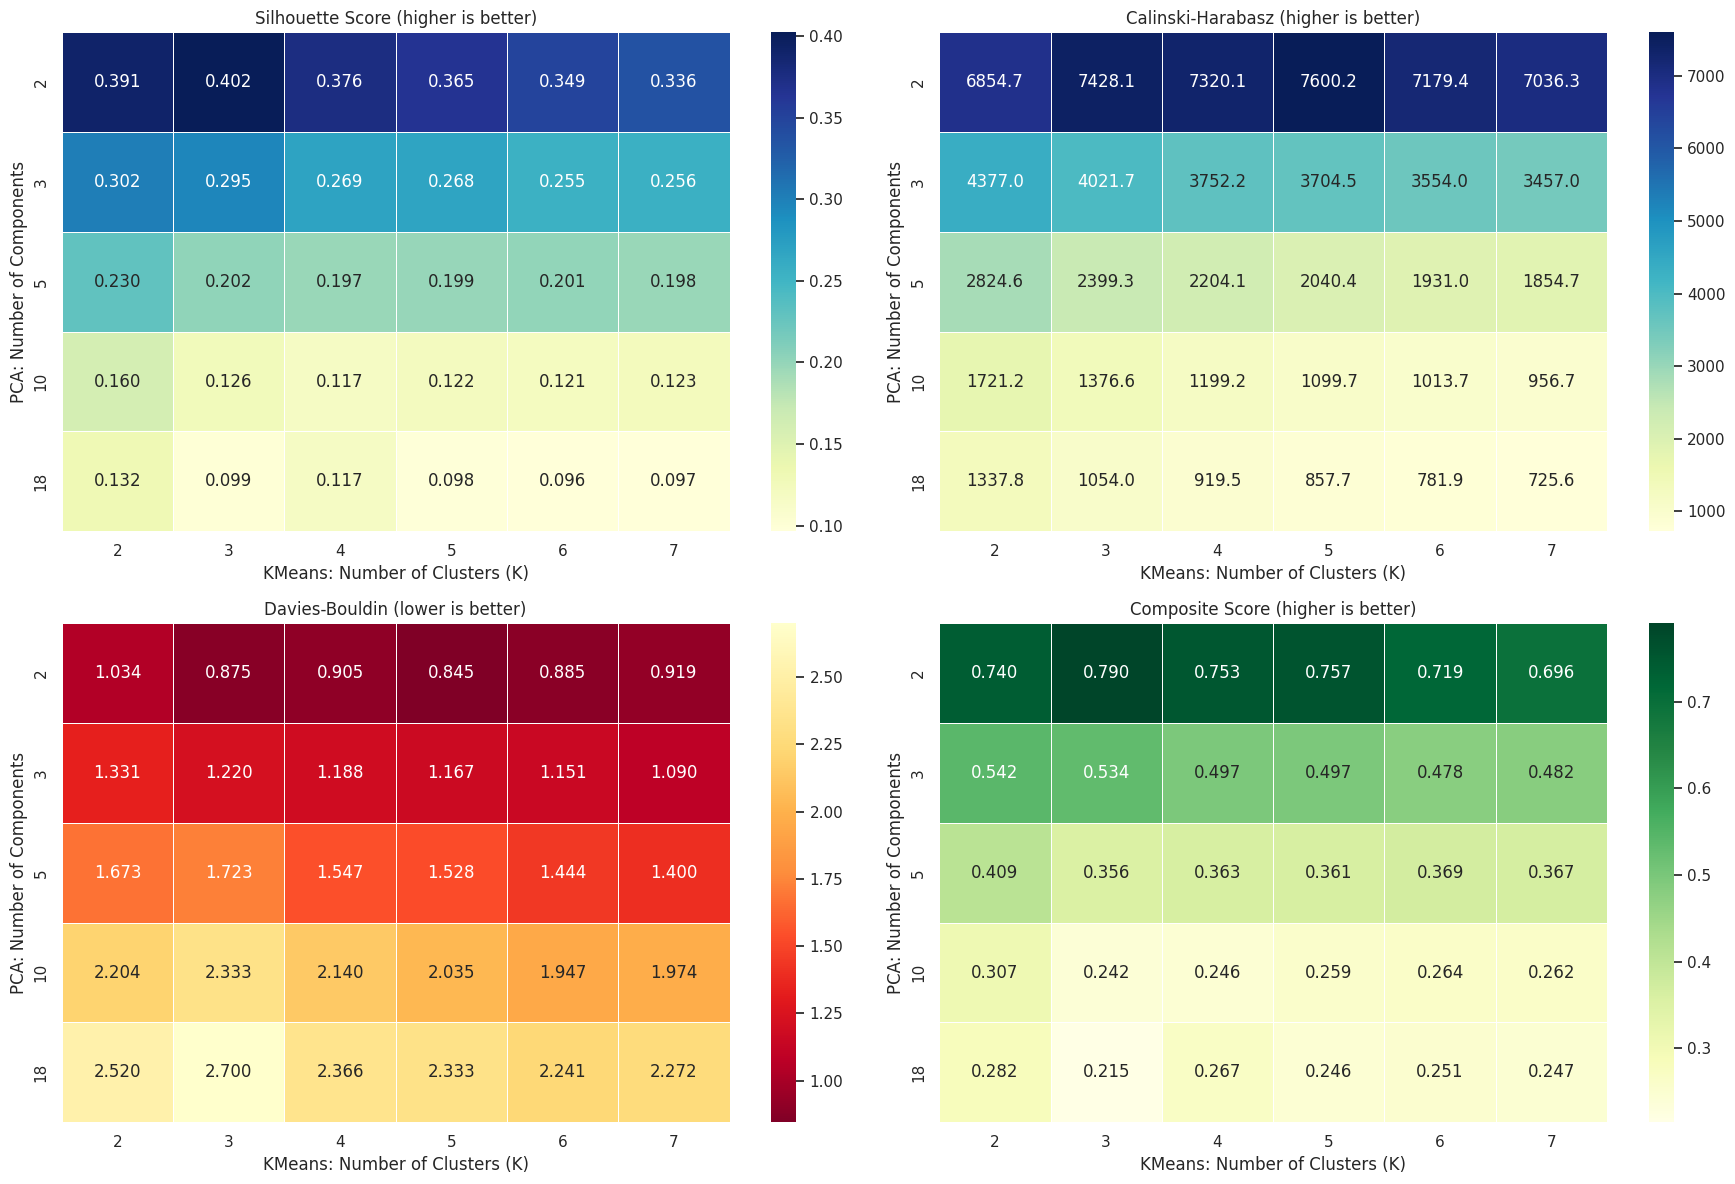

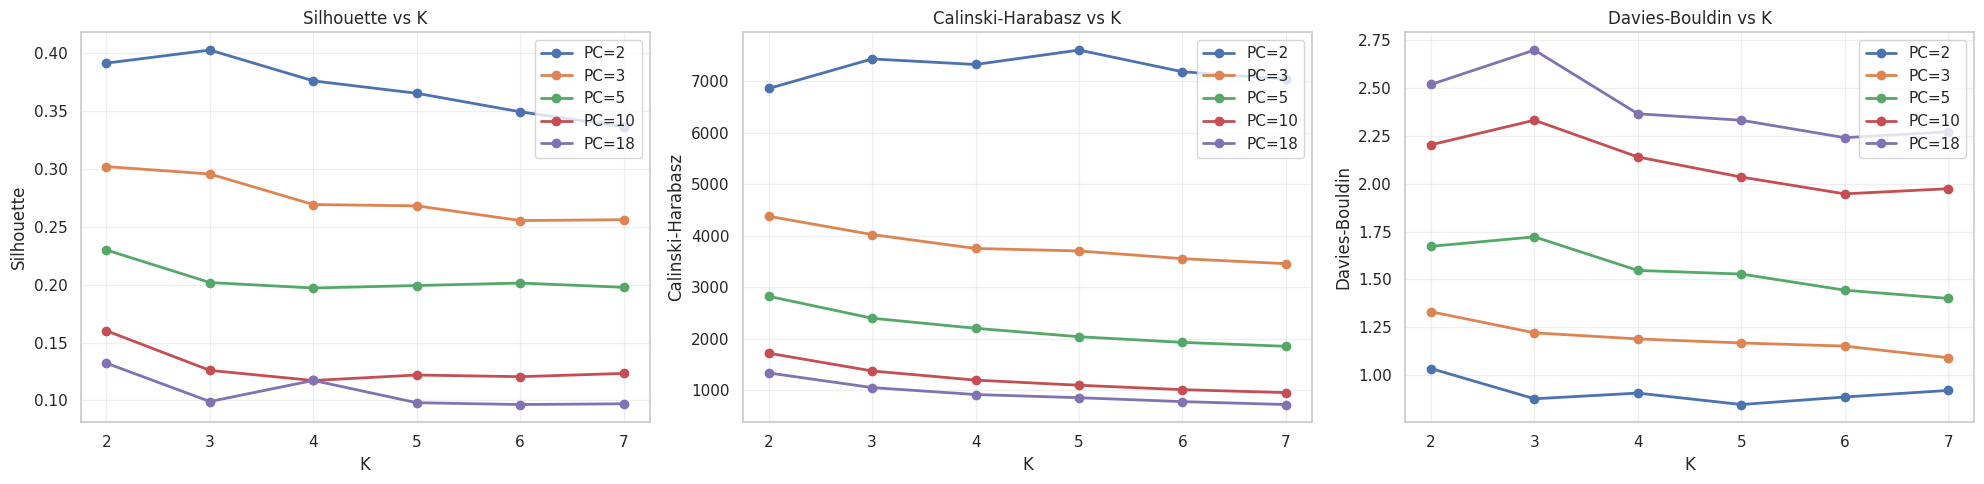

In [17]:
plot_grid_search_heatmaps(grid_results_df)
plot_metric_lines(grid_results_df)

best_combo_summary = pd.DataFrame([{
    'Best PCA Components': best_grid_result['best_pca_components'],
    'Best K': best_grid_result['best_k'],
    'Cumulative Variance Captured': best_grid_result['best_explained_variance'],
    'Best Composite Score': grid_results_df.iloc[0]['composite_score'],
    'Silhouette': grid_results_df.iloc[0]['silhouette'],
    'Calinski-Harabasz': grid_results_df.iloc[0]['calinski_harabasz'],
    'Davies-Bouldin': grid_results_df.iloc[0]['davies_bouldin']
}])

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:4761 │
│ in _parse_scatter_color_args                                                                     │
│                                                                                                  │
│   4758 │   │   │   │   │   valid_shape = False                                                   │
│   4759 │   │   if not c_is_mapped:                                                               │
│   4760 │   │   │   try:  # Is 'c' acceptable as PathCollection facecolors?                       │
│ ❱ 4761 │   │   │   │   colors = mcolors.to_rgba_array(c)                                         │
│   4762 │   │   │   except (TypeError, ValueError) as err:                                        │
│   4763 │   │   │   │   if "RGBA values should be within 0-1 range" in str(err):                  │
│   4764 │   │   │   │   │   raise                                                                 │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/matplotlib/colors.py:515 in   │
│ to_rgba_array                                                                                    │
│                                                                                                  │
│    512 │   │   else:                                                                             │
│    513 │   │   │   rgba = np.array([to_rgba(cc) for cc in c])                                    │
│    514 │   else:                                                                                 │
│ ❱  515 │   │   rgba = np.array([to_rgba(cc) for cc in c])                                        │
│    516 │                                                                                         │
│    517 │   if alpha is not None:                                                                 │
│    518 │   │   rgba[:, 3] = alpha                                                                │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/matplotlib/colors.py:317 in   │
│ to_rgba                                                                                          │
│                                                                                                  │
│    314 │   except (KeyError, TypeError):  # Not in cache, or unhashable.                         │
│    315 │   │   rgba = None                                                                       │
│    316 │   if rgba is None:  # Suppress exception chaining of cache lookup failure.              │
│ ❱  317 │   │   rgba = _to_rgba_no_colorcycle(c, alpha)                                           │
│    318 │   │   try:                                                                              │
│    319 │   │   │   _colors_full_map.cache[c, alpha] = rgba                                       │
│    320 │   │   except TypeError:                                                                 │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/matplotlib/colors.py:394 in   │
│ _to_rgba_no_colorcycle                                                                           │
│                                                                                                  │
│    391 │   │   │   │   │   f"Invalid string grayscale value {orig_c!r}. "                        │
│    392 │   │   │   │   │   f"Value must be within 0-1 range")                                    │
│    393 │   │   │   return c, c, c, alpha if alpha is not No

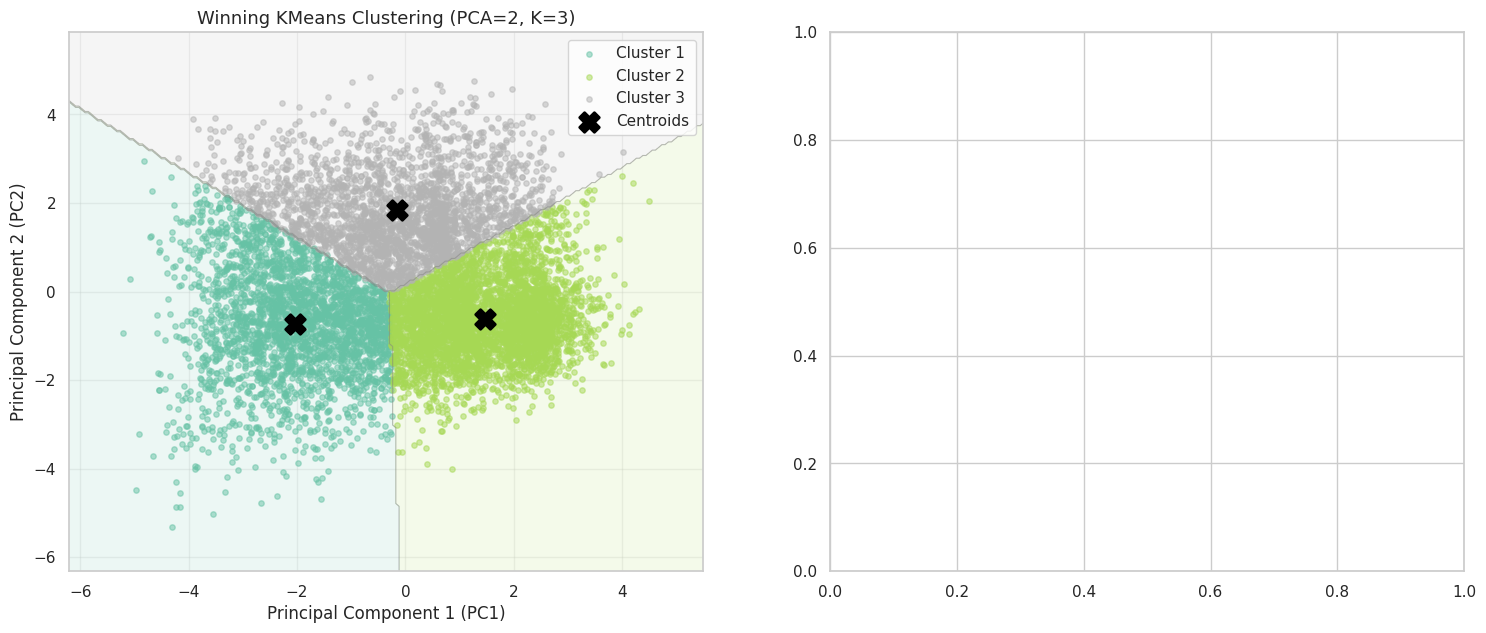

In [22]:
def visualize_best_grid_result(best_grid_result, sale_price, df_features):
    """
    Visualize the winning (PCA components, K) combination.

    If best PCA dimensionality > 2:
      - Clustering is still done in full PCA space, plot shows only the first two PCs for visualization.
    """

    pca_np = best_grid_result['best_pca_np']
    labels = best_grid_result['best_labels']
    centroids = best_grid_result['best_centroids']
    best_k = best_grid_result['best_k']
    best_pca_components = best_grid_result['best_pca_components']

    # First 2 PCs for plotting
    plot_x = pca_np[:, 0]
    plot_y = pca_np[:, 1]
    centroid_x = centroids[:, 0]
    centroid_y = centroids[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    colors = plt.cm.Set2(np.linspace(0, 1, best_k))

    if best_pca_components == 2:
        # Exact 2D decision regions only if clustering itself is 2D
        x_min, x_max = plot_x.min() - 1, plot_x.max() + 1
        y_min, y_max = plot_y.min() - 1, plot_y.max() + 1
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200)
        )
        grid_points = np.c_[xx.ravel(), yy.ravel()].astype('float32')

        # Distances in exact 2D PCA space
        grid_distances = np.sqrt(((grid_points[:, np.newaxis, :] - centroids[np.newaxis, :, :])**2).sum(axis=2))
        grid_labels = np.argmin(grid_distances, axis=1).reshape(xx.shape)

        axes[0].contourf(
            xx, yy, grid_labels,
            levels=np.arange(best_k + 1) - 0.5,
            colors=colors,
            alpha=0.12
        )
        axes[0].contour(
            xx, yy, grid_labels,
            levels=np.arange(best_k + 1) - 0.5,
            colors='gray',
            linewidths=0.8,
            alpha=0.5
        )

    for i in range(best_k):
        mask = labels == i
        axes[0].scatter(
            plot_x[mask],
            plot_y[mask],
            c=[colors[i]],
            alpha=0.5,
            s=15,
            label=f'Cluster {i+1}'
        )

    axes[0].scatter(
        centroid_x,
        centroid_y,
        c='black',
        marker='X',
        s=200,
        linewidths=2,
        label='Centroids'
    )

    title_suffix = f'PCA={best_pca_components}, K={best_k}'
    axes[0].set_title(f'Winning KMeans Clustering ({title_suffix})', fontsize=13)
    axes[0].set_xlabel('Principal Component 1 (PC1)')
    axes[0].set_ylabel('Principal Component 2 (PC2)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if best_pca_components > 2:
        axes[0].text(
            0.01, 0.01,
            f'Clusters were fit in {best_pca_components}D PCA space.\nThis plot shows the projection onto PC1-PC2.',
            transform=axes[0].transAxes,
            fontsize=10,
            va='bottom',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='gray')
        )

    scatter = axes[1].scatter(
        plot_x,
        plot_y,
        c=sale_price.values,
        cmap='RdYlGn',
        alpha=0.5,
        s=15
    )

    axes[1].scatter(
        centroid_x,
        centroid_y,
        c='black',
        marker='X',
        s=200,
        linewidths=2,
        label='Centroids'
    )

    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('SalePrice ($)')

    axes[1].set_title(f'Same Projection Colored by SalePrice ({title_suffix})', fontsize=13)
    axes[1].set_xlabel('Principal Component 1 (PC1)')
    axes[1].set_ylabel('Principal Component 2 (PC2)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    cluster_labels_text = [f'Cluster {c+1}' for c in labels]
    box_df = pd.DataFrame({
        'Cluster': cluster_labels_text,
        'SalePrice': sale_price.values
    })

    plt.figure(figsize=(10, 6))
    cluster_order = (
        box_df.groupby('Cluster')['SalePrice']
        .median()
        .sort_values()
        .index.tolist()
    )

    sns.boxplot(
        data=box_df,
        x='Cluster',
        y='SalePrice',
        hue='Cluster',
        order=cluster_order,
        palette='Set2',
        legend=False
    )

    plt.title(f'SalePrice Distribution by Cluster ({title_suffix})', fontsize=13)
    plt.xlabel('Cluster')
    plt.ylabel('SalePrice ($)')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print(f"\nCluster Summary ({title_suffix}):")
    summary_data = []
    for i in range(best_k):
        mask = labels == i
        cluster_prices = sale_price.values[mask]
        summary_data.append([
            f'Cluster {i+1}',
            int(mask.sum()),
            f'${cluster_prices.mean():,.0f}',
            f'${np.median(cluster_prices):,.0f}',
            f'${cluster_prices.min():,.0f}',
            f'${cluster_prices.max():,.0f}'
        ])

    headers = ['Cluster', 'Count', 'Mean Price', 'Median Price', 'Min Price', 'Max Price']
    print(tabulate(summary_data, headers=headers))

    cluster_profiles = build_cluster_profile_table(labels, sale_price, df_features)

    print(f"\nCluster Profiles (sorted by average price):")
    display(cluster_profiles)

    print(f"\nCluster Descriptions:")
    for _, row in cluster_profiles.iterrows():
        print(f" Cluster {int(row['Cluster'])}: {row['Description']}")

    return cluster_profiles


best_cluster_profiles = visualize_best_grid_result(
    best_grid_result=best_grid_result,
    sale_price=attrition_flag,
    df_features=df_features
)

In [23]:
def train_final_sagemaker_kmeans_on_best_combo(
    best_grid_result,
    sagemaker_session,
    role,
    bucket,
    prefix,
    sagemaker_client
):
    """
    Train one final SageMaker KMeans model on the winning PCA representation and creates a SageMaker model artifact that can deploy.
    """
    best_pca_np = best_grid_result['best_pca_np'].astype('float32')
    best_pca_components = best_grid_result['best_pca_components']
    best_k = best_grid_result['best_k']

    output_path = f's3://{bucket}/{prefix}/grid-best-kmeans/output'
    timestamp = time.strftime('%Y%m%d-%H%M%S')
    job_name = f'kmeans-ames-gridbest-pca{best_pca_components}-k{best_k}-{timestamp}'

    final_kmeans = sagemaker.KMeans(
        sagemaker_session=sagemaker_session,
        role=role,
        instance_count=1,
        instance_type='ml.m5.large',
        k=best_k,
        output_path=output_path,
        feature_dim=best_pca_components
    )

    print(f"Starting final SageMaker KMeans training job: {job_name}")
    final_kmeans.fit(
        final_kmeans.record_set(best_pca_np),
        wait=True,
        job_name=job_name
    )

    job_description = sagemaker_client.describe_training_job(TrainingJobName=job_name)
    model_s3_uri = job_description['ModelArtifacts']['S3ModelArtifacts']

    print("Final SageMaker model artifact:")
    print(model_s3_uri)

    return [(best_k, model_s3_uri)]


final_grid_kmeans_model_paths = train_final_sagemaker_kmeans_on_best_combo(
    best_grid_result=best_grid_result,
    sagemaker_session=sagemaker_session,
    role=role,
    bucket=bucket,
    prefix=prefix,
    sagemaker_client=sagemaker_client
)

Starting final SageMaker KMeans training job: kmeans-ames-gridbest-pca2-k3-20260321-013830


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-ames-gridbest-pca2-k3-20260321-013830


2026-03-21 01:38:31 Starting - Starting the training job...
2026-03-21 01:38:46 Starting - Preparing the instances for training...
2026-03-21 01:39:07 Downloading - Downloading input data...
2026-03-21 01:39:52 Downloading - Downloading the training image.......Docker entrypoint called with argument(s): train
Running default environment configuration script
[03/21/2026 01:41:09 INFO 139657517815616] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'init_method': 'random', 'mini_batch_size': '5000', 'epochs': '1', 'extra_center_factor': 'auto', 'local_lloyd_max_iter': '300', 'local_lloyd_tol': '0.0001', 'local_lloyd_init_method': 'kmeans++', 'local_lloyd_num_trials': 'auto', 'half_life_time_size': '0', 'eval_metrics': '["msd"]', 'force_dense': 'true', '_disable_wait_to_read': 'false', '_enable_profiler': 'false', '_kvstore': 'auto', '_log_level': 'info', '_num_gpus': 'auto', '_num_kv_servers': '1', '_num_slices': '1', '_

In [24]:
# Keep original baseline values 
baseline_num_pca_components = num_pca_components
baseline_best_k = best_k
baseline_pca_df = pca_df.copy()
baseline_pca_np = pca_np.copy()
baseline_kmeans_model_paths = kmeans_model_paths

# Replace with winning combo
num_pca_components = best_grid_result['best_pca_components']
best_k = best_grid_result['best_k']
pca_df = best_grid_result['best_pca_df'].copy()
pca_np = best_grid_result['best_pca_np'].copy()
pca_components_matrix = best_grid_result['best_components_matrix'].copy()
kmeans_model_paths = final_grid_kmeans_model_paths

## What to Look For

**Plot 1 (Clusters):** Are the clusters well-separated or overlapping? With ~74 dense features, PCA captured more variance in 2 components, so you should see cleaner separation compared to Demo 1.

**Plot 2 (SalePrice validation):** This is the key test. The model never saw SalePrice as a feature, so if the color gradient (green = expensive, red = cheap) aligns with the cluster boundaries, it means the algorithm found real housing market segments. Look for whether expensive homes (green) cluster together and cheaper homes (red) cluster separately.

**A note on target encoding and validation:** You may notice that the clusters align particularly well with SalePrice tiers in this demo. Part of this is because our target encoding in Step 4 embedded SalePrice information into the nominal features. For example, every home in "NridgHt" (Northridge Heights) was encoded as ~\$316,000 and every home in "OldTown" as ~\$128,000. When we now color the clusters by SalePrice and see strong alignment, that alignment is partially by design, not purely discovered.

This is a legitimate technique in unsupervised learning because there is no prediction target to leak into, but it is an important tradeoff to understand. In Demo 1, where no SalePrice information was used in encoding, any cluster-to-price alignment is entirely organic. Both approaches are valid: Demo 2 gives PCA richer inputs at the cost of partially circular validation, while Demo 1 keeps the validation fully independent.

**Plot 3 (Box plot):** Each box shows the price distribution within a cluster. Look for:
- **Separation between medians:** Different clusters should have noticeably different median prices
- **Box overlap:** Some overlap is normal, but the medians should follow a clear progression

**Cluster Profiles table:** Read the plain-English descriptions. Do the clusters make intuitive business sense? For example, you might see segments like "budget tier, lower quality, smaller homes, older construction" vs. "premium tier, high quality, spacious homes, recent construction."

**Compare with Demo 1:** The denser encoding typically produces more meaningful and better-separated clusters, validating that data preparation choices have a direct impact on unsupervised learning quality.

## Business Application: Turning Clusters into Strategy

The cluster profiles above are not just a technical exercise. In a real business context, these segments would drive concrete decisions:

**Customer Segmentation and Targeted Marketing:**
- Each cluster represents a distinct housing market segment with different price points, quality levels, and home characteristics
- A real estate company could tailor marketing materials, listing descriptions, and advertising channels to each segment
- For example, "Premium tier" homes might be marketed through luxury channels with professional staging, while "Budget tier" homes might emphasize value and potential

**Pricing Strategy:**
- New listings can be run through the prediction pipeline to identify which segment they belong to, providing an instant price range estimate
- Homes that fall near cluster boundaries may represent opportunities for repositioning through renovations

**Inventory and Investment Analysis:**
- Developers can identify which segments are underserved in a market
- Investors can target specific clusters based on their risk and return preferences

**Key Insight:** None of this required telling the model about price. The algorithm discovered these segments purely from physical characteristics, quality ratings, and location features. The fact that the clusters align with price tiers validates that the model found real market structure, not just random groupings.

**Compare with Demo 1:** The optimized encoding in this demo (~74 dense features vs ~200 sparse features) typically produces cleaner cluster boundaries and more distinct segments, demonstrating that data preparation choices directly impact the quality of unsupervised learning results.

# STEP 13: DEPLOY KMEANS MODEL TO ENDPOINT

Deploy the best KMeans model (with optimal K) to a real-time SageMaker endpoint for predictions. This allows us to send new PCA-transformed data points and receive cluster assignments.

**What is about to happen:**
- Delete any existing endpoint with the same name (to avoid conflicts)
- Create a SageMaker Model object from the best KMeans model artifacts
- Deploy it to an `ml.m5.large` instance as a real-time endpoint
- This may take 3-5 minutes while AWS provisions the instance

In [50]:
def delete_endpoint_and_config(endpoint_name, sagemaker_client):
    """
    Delete a SageMaker endpoint and its endpoint configuration if they exist.
    Polls until both resources are fully deleted.

    This function is defined here in the deploy step and reused in the
    cleanup step (STEP 14) without duplication.

    Parameters:
        endpoint_name (str): The name of the endpoint to delete.
        sagemaker_client: The Boto3 SageMaker client.
    """
    # Delete endpoint if it exists
    try:
        sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
        print(f'Deleting endpoint: {endpoint_name}')
        sagemaker_client.delete_endpoint(EndpointName=endpoint_name)
    except ClientError as e:
        if e.response['Error']['Code'] == 'ValidationException' and 'Could not find' in e.response['Error']['Message']:
            print(f'Endpoint "{endpoint_name}" does not exist.')
        else:
            raise

    # Delete endpoint config if it exists
    try:
        sagemaker_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        print(f'Deleting endpoint configuration: {endpoint_name}')
        sagemaker_client.delete_endpoint_config(EndpointConfigName=endpoint_name)
    except ClientError as e:
        if e.response['Error']['Code'] == 'ValidationException' and 'Could not find' in e.response['Error']['Message']:
            print(f'Endpoint config "{endpoint_name}" does not exist.')
        else:
            raise

    # Poll for deletion
    print('Waiting for resources to be deleted...')
    for _ in range(30):
        endpoint_exists = True
        config_exists = True

        try:
            sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
        except ClientError:
            endpoint_exists = False

        try:
            sagemaker_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        except ClientError:
            config_exists = False

        if not endpoint_exists and not config_exists:
            print('Endpoint and endpoint config fully deleted.')
            break

        time.sleep(10)
    else:
        print('Warning: resources may not be fully deleted after 30 checks.')


def deploy_kmeans_endpoint(kmeans_model_paths, best_k, endpoint_name, kmeans_image_uri, role, sagemaker_session, sagemaker_client):
    """
    Deploy the best KMeans model to a SageMaker real-time endpoint.
    Deletes any existing endpoint with the same name first.

    Parameters:
        kmeans_model_paths (list): List of (k, s3_uri) tuples.
        best_k (int): The optimal number of clusters.
        endpoint_name (str): The name for the endpoint.
        kmeans_image_uri (str): The KMeans Docker image URI.
        role (str): The IAM role ARN.
        sagemaker_session: The SageMaker session.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        Predictor: The SageMaker Predictor object for making predictions.
    """
    # Delete any existing endpoint first
    delete_endpoint_and_config(endpoint_name, sagemaker_client)

    # Get the best model S3 URI
    best_model_s3_uri = next(path for k, path in kmeans_model_paths if k == best_k)

    # Create a SageMaker Model object
    best_model = Model(
        model_data=best_model_s3_uri,
        image_uri=kmeans_image_uri,
        role=role,
        sagemaker_session=sagemaker_session
    )

    # Deploy the model to an endpoint
    print(f'\nDeploying KMeans model (K={best_k}) to endpoint: {endpoint_name}')
    print('This may take several minutes...')

    predictor = best_model.deploy(
        endpoint_name=endpoint_name,
        initial_instance_count=1,
        instance_type='ml.m5.large'
    )

    print(f'\nEndpoint "{endpoint_name}" deployed successfully!')
    return predictor


endpoint_name = 'ames-pca-kmeans-demo2'
predictor = deploy_kmeans_endpoint(
    kmeans_model_paths, best_k, endpoint_name,
    kmeans_image_uri, role, sagemaker_session, sagemaker_client
)

# Configure the predictor serializer for CSV input
predictor = Predictor(endpoint_name=endpoint_name, serializer=CSVSerializer())

Deleting endpoint: ames-pca-kmeans-demo2
Deleting endpoint configuration: ames-pca-kmeans-demo2
Waiting for resources to be deleted...


INFO:sagemaker:Creating model with name: kmeans-2026-03-08-00-32-05-085


Endpoint and endpoint config fully deleted.

Deploying KMeans model (K=2) to endpoint: ames-pca-kmeans-demo2
This may take several minutes...


INFO:sagemaker:Creating endpoint-config with name ames-pca-kmeans-demo2
INFO:sagemaker:Creating endpoint with name ames-pca-kmeans-demo2


-------!
Endpoint "ames-pca-kmeans-demo2" deployed successfully!


## What to Look For

You should see the endpoint being created and eventually a success message. The endpoint name is `ames-pca-kmeans-demo2`.

**Important:** The endpoint will continue incurring charges until you delete it in STEP 14. Do not skip the cleanup step.

# STEP 14: INTERACTIVE PREDICTION

This step demonstrates the full real-world ML pipeline: a user enters raw housing feature values (Overall Quality, Living Area, etc.), and the code applies the same preprocessing, standardization, and PCA transformation before sending the result to the KMeans endpoint.

**What is about to happen:**
- First, three pre-built example homes run automatically to show how different homes land in different clusters
- Then, you will be prompted to enter 5 key housing features (quality, size, year, basement, garage)
- All other features are filled with **quality-conditional medians** (not global medians), so a quality-9 home gets realistic premium defaults for correlated features like Exter Qual, Kitchen Qual, Year Built, etc.
- The code applies: log-transformation (for skewed features) then standardization (StandardScaler) then PCA transformation then KMeans prediction
- The result shows which cluster the home belongs to, along with the cluster profile

**Why quality-conditional defaults matter:** The KMeans model uses ~74 features, but users only enter 5. The other ~69 features must be filled with realistic values. Using global medians (the overall dataset median) makes every prediction look like a mid-range home regardless of the 5 user inputs, because the ~69 default features dominate the PCA projection. Instead, we group the training data by Overall Qual and compute medians within each quality level. A quality-9 home gets quality-9 medians for Exter Qual, Kitchen Qual, Garage Finish, etc., pulling the prediction into the premium cluster where it belongs.

**Why the extra log-transform step matters:** Because we log-transformed certain features during training (Step 4), we must apply the same transformation to new predictions. The StandardScaler was fitted on log-transformed data, so feeding it raw values would produce incorrect scaled values, which would produce incorrect PCA coordinates, which would produce incorrect cluster assignments. This is the cost of a more sophisticated pipeline, but the better cluster quality is worth it. Compare this to Demo 1, where prediction only requires standardization and PCA (no log step).

**The automatic examples include:**
- A luxury home (Quality=9, 3,000 sq ft, built 2010)
- A starter home (Quality=5, 900 sq ft, built 1975)
- A fixer-upper (Quality=3, 1,100 sq ft, built 1950)

**Then try your own scenarios:**
- Your dream home: enter whatever values you like!

Type `quit` at any prompt to exit.

In [ ]:
def interactive_prediction(predictor, scaler, pca_components_matrix, df_features, feature_names, cluster_profiles=None, log_transformed_cols=None):
    """
    Accept user input for key housing features, apply the full preprocessing +
    standardization + PCA pipeline, then send to the KMeans endpoint for cluster
    assignment. If cluster profiles are provided, display the profile for the
    predicted cluster so the user understands what the cluster means.

    The user enters values for a few key features. All other features are filled
    with quality-conditional median values from the training data. This means a
    quality-9 home gets realistic defaults for Exter Qual, Kitchen Qual, etc.,
    rather than global medians that anchor everything to the mid-range cluster.

    Parameters:
        predictor: The SageMaker Predictor for the KMeans endpoint.
        scaler (StandardScaler): The fitted scaler from STEP 5.
        pca_components_matrix (np.ndarray): The PCA transformation matrix from STEP 8.
        df_features (pd.DataFrame): The preprocessed feature DataFrame for defaults.
        feature_names (list): The list of feature column names.
        cluster_profiles (pd.DataFrame): Optional cluster profile data from STEP 11.
        log_transformed_cols (list): Column names that were log-transformed in
            preprocessing. Raw user inputs for these columns must be log1p-transformed
            before scaling, because the scaler was fitted on log-transformed data.
    """
    # Define the key features the user will enter
    # These are the most intuitive housing features for students to understand
    user_features = {
        'Overall Qual': ('Overall Quality (1-10)', 1, 10),
        'Gr Liv Area': ('Above-Ground Living Area (sq ft)', 300, 6000),
        'Year Built': ('Year Built (e.g. 1990)', 1870, 2025),
        'Total Bsmt SF': ('Total Basement Area (sq ft, 0 if none)', 0, 6000),
        'Garage Area': ('Garage Area (sq ft, 0 if none)', 0, 1500)
    }

    # Compute quality-conditional medians for all features.
    # Instead of global medians (which anchor all predictions to the mid-range
    # cluster regardless of input), we group by Overall Qual so that a quality-9
    # home gets realistic premium defaults for correlated features like Exter Qual,
    # Kitchen Qual, Year Built, Garage Area, etc.
    quality_medians = df_features.groupby('Overall Qual').median()
    # Note: groupby moves 'Overall Qual' to the index, so the median
    # Series has N-1 columns. We add it back in get_defaults_for_quality.
    global_medians = df_features.median()

    def get_defaults_for_quality(qual_value):
        """Return the median feature vector for the given quality level."""
        if qual_value in quality_medians.index:
            defaults = quality_medians.loc[qual_value].copy()
        else:
            # Find the closest available quality level
            closest = quality_medians.index[np.argmin(np.abs(quality_medians.index - qual_value))]
            defaults = quality_medians.loc[closest].copy()
        # groupby() moves 'Overall Qual' to the index, dropping it from
        # the result. Add it back so the feature count matches the scaler.
        defaults['Overall Qual'] = qual_value
        # Reorder to match df_features column order (scaler expects this)
        defaults = defaults.reindex(df_features.columns)
        return defaults

    print("PCA + KMeans Cluster Prediction")
    print("Enter housing features for a prediction, or type 'quit' to exit.")
    print(f"(Other features auto-adjust based on quality level)\n")


    # --- Run pre-built example predictions automatically ---
    example_homes = [
        {'name': 'Luxury Home',   'Overall Qual': 9, 'Gr Liv Area': 3000, 'Year Built': 2010, 'Total Bsmt SF': 2000, 'Garage Area': 800},
        {'name': 'Starter Home',  'Overall Qual': 5, 'Gr Liv Area': 900,  'Year Built': 1975, 'Total Bsmt SF': 600,  'Garage Area': 300},
        {'name': 'Fixer-Upper',   'Overall Qual': 3, 'Gr Liv Area': 1100, 'Year Built': 1950, 'Total Bsmt SF': 500,  'Garage Area': 0},
    ]

    print("=" * 65)
    print("EXAMPLE PREDICTIONS: Three pre-built homes")
    print("=" * 65)

    for example in example_homes:
        # Use quality-conditional defaults instead of global medians
        qual = example.get('Overall Qual', 6)
        input_data = get_defaults_for_quality(qual)

        # Override with example values
        for feat, val in example.items():
            if feat != 'name' and feat in input_data.index:
                input_data[feat] = val

        # Apply log1p ONLY to the user-entered features that need it.
        # The median defaults from df_features are ALREADY log-transformed
        # (preprocess_data applied log1p in step 7), so re-applying would
        # double-log them and distort the PCA projection.
        if log_transformed_cols:
            log_col_set = set(log_transformed_cols)
            for feat_name in example:
                if feat_name != 'name' and feat_name in log_col_set and feat_name in input_data.index:
                    input_data[feat_name] = np.log1p(input_data[feat_name])

        # Apply the same pipeline: standardize -> PCA -> predict
        input_array = input_data.values.reshape(1, -1).astype('float32')
        input_scaled = scaler.transform(input_array).astype('float32')
        input_pca = input_scaled @ pca_components_matrix
        pca_csv = ','.join([str(v) for v in input_pca.flatten()])

        print(f"\n--- {example['name']} ---")
        print(f"  Quality={example['Overall Qual']}, "
              f"Area={example['Gr Liv Area']:,} sq ft, "
              f"Year={example['Year Built']}, "
              f"Basement={example['Total Bsmt SF']:,} sq ft, "
              f"Garage={example['Garage Area']} sq ft")

        try:
            response = predictor.predict(pca_csv)
            response_json = json.loads(response)
            cluster = int(response_json['predictions'][0]['closest_cluster'])
            distance = response_json['predictions'][0]['distance_to_cluster']

            print(f"  Result: Cluster {cluster + 1} (distance: {distance:.4f})")
            print(f"  PCA values: PC1={input_pca[0,0]:.4f}, PC2={input_pca[0,1]:.4f}")

            if cluster_profiles is not None:
                profile = cluster_profiles[cluster_profiles['Cluster'] == cluster + 1]
                if not profile.empty:
                    row = profile.iloc[0]
                    print(f"  Profile: {row['Description']}")
                    print(f"    Avg Sale Price: ${row['Avg_SalePrice']:,.0f}")
        except Exception as e:
            print(f"  Error during prediction: {e}")

    print(f"\n{'=' * 65}")
    print("YOUR TURN: Enter your own housing features below")
    print(f"{'=' * 65}\n")

    while True:
        # Collect user inputs (get quality first to select defaults)
        quit_flag = False
        user_values = {}

        for feature_name, (prompt_text, min_val, max_val) in user_features.items():
            while True:
                user_input = input(f"  {prompt_text}: ").strip()
                if user_input.lower() == 'quit':
                    quit_flag = True
                    break
                try:
                    value = float(user_input)
                    if min_val <= value <= max_val:
                        user_values[feature_name] = value
                        break
                    else:
                        print(f"    Please enter a value between {min_val} and {max_val}.")
                except ValueError:
                    print(f"    Invalid input. Please enter a number.")

            if quit_flag:
                break

        if quit_flag:
            break

        # Use quality-conditional defaults based on the entered quality level
        qual = user_values.get('Overall Qual', 6)
        input_data = get_defaults_for_quality(qual)

        # Override with user-provided values
        for feature_name, value in user_values.items():
            if feature_name in input_data.index:
                input_data[feature_name] = value

        # Apply log1p ONLY to user-entered features that need it.
        # Median defaults are already log-transformed from preprocess_data.
        if log_transformed_cols:
            log_col_set = set(log_transformed_cols)
            for feat_name in user_features:
                if feat_name in log_col_set and feat_name in input_data.index:
                    input_data[feat_name] = np.log1p(input_data[feat_name])

        # Convert to NumPy array in the correct feature order
        input_array = input_data.values.reshape(1, -1).astype('float32')

        # Apply the same standardization
        input_scaled = scaler.transform(input_array).astype('float32')

        # Apply the same PCA transformation
        input_pca = input_scaled @ pca_components_matrix

        # Send PCA-transformed values to the KMeans endpoint
        pca_csv = ','.join([str(v) for v in input_pca.flatten()])

        try:
            response = predictor.predict(pca_csv)
            response_json = json.loads(response)
            cluster = int(response_json['predictions'][0]['closest_cluster'])
            distance = response_json['predictions'][0]['distance_to_cluster']

            print(f"\n  Result: This home belongs to Cluster {cluster + 1} (distance to centroid: {distance:.4f})")
            print(f"  PCA values: PC1={input_pca[0,0]:.4f}, PC2={input_pca[0,1]:.4f}")

            # Display cluster profile if available
            if cluster_profiles is not None:
                profile = cluster_profiles[cluster_profiles['Cluster'] == cluster + 1]
                if not profile.empty:
                    row = profile.iloc[0]
                    print(f"\n  Cluster {cluster + 1} Profile: {row['Description']}")
                    print(f"    Avg Sale Price:    ${row['Avg_SalePrice']:,.0f}")
                    if 'Avg_Overall_Qual' in row:
                        print(f"    Avg Overall Qual:  {row['Avg_Overall_Qual']:.1f}")
                    if 'Avg_Gr_Liv_Area' in row:
                        print(f"    Avg Living Area:   {row['Avg_Gr_Liv_Area']:,.0f} sq ft")
                    if 'Avg_Year_Built' in row:
                        print(f"    Avg Year Built:    {row['Avg_Year_Built']:.0f}")
                    if 'Avg_Total_Bsmt_SF' in row:
                        print(f"    Avg Basement Area: {row['Avg_Total_Bsmt_SF']:,.0f} sq ft")
                    if 'Avg_Garage_Area' in row:
                        print(f"    Avg Garage Area:   {row['Avg_Garage_Area']:,.0f} sq ft")
        except Exception as e:
            print(f"\n  Error during prediction: {e}")

        print()  # Blank line before next iteration

    print("\nPrediction program exited.")


interactive_prediction(predictor, scaler, pca_components_matrix, df_features, feature_names, cluster_profiles, log_transformed_cols)

PCA + KMeans Cluster Prediction
Enter housing features for a prediction, or type 'quit' to exit.
(All other features will use training data median values)

EXAMPLE PREDICTIONS: Three pre-built homes

--- Luxury Home ---
  Quality=9, Area=3,000 sq ft, Year=2010, Basement=2,000 sq ft, Garage=800 sq ft


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  Result: Cluster 2 (distance: 2.8377)
  PCA values: PC1=2.4088, PC2=-2.4571
  Profile: Budget tier, lower quality, smaller homes, older construction
    Avg Sale Price: $132,952

--- Starter Home ---
  Quality=5, Area=900 sq ft, Year=1975, Basement=600 sq ft, Garage=300 sq ft
  Result: Cluster 2 (distance: 3.6455)
  PCA values: PC1=4.9250, PC2=-2.0841
  Profile: Budget tier, lower quality, smaller homes, older construction
    Avg Sale Price: $132,952

--- Fixer-Upper ---
  Quality=3, Area=1,100 sq ft, Year=1950, Basement=500 sq ft, Garage=0 sq ft
  Result: Cluster 2 (distance: 4.2848)
  PCA values: PC1=5.6248, PC2=-2.2443
  Profile: Budget tier, lower quality, smaller homes, older construction
    Avg Sale Price: $132,952

YOUR TURN: Enter your own housing features below



/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# STEP 15: CLEANUP

Delete the SageMaker endpoint and endpoint configuration to stop incurring charges. This reuses the `delete_endpoint_and_config` function defined in STEP 12.

**Important:** SageMaker endpoints charge by the hour. Always run this cell when you are done to avoid unexpected costs on your AWS account.

In [ ]:
# ⚠️ AWS COST WARNING ⚠️
# SageMaker endpoints incur charges as long as they are running.
# Make sure to delete your endpoint when you are done to avoid unexpected costs.

response = input("Are you sure you want to delete the endpoint? (yes/no): ").strip().lower()
if response == 'yes':
    delete_endpoint_and_config(endpoint_name, sagemaker_client)
    print("\nEndpoint cleanup complete.")
else:
    print("\nEndpoint was NOT deleted. Remember to delete it later to avoid charges.")